# NFL Player Performance - Trening i validacija modela

Ovaj notebook predstavlja kompletan pipeline koji obuhvata predprocesiranje podataka, treniranje modela i njihovu evaluaciju. Ovaj notebook predstavlja nastavak EDA.ipynb i sve odluke i tehnike uradjene ovde, odredjenje su tokom ekplorativne analize prikazane u tom notebook-u.

### Predprocesiranje podataka

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(''))

import warnings
warnings.filterwarnings('ignore')

from modeling.data_preprocessing import *
from modeling.missing_values import *
from modeling.lag_feature import *
from modeling.dataset_split import *
from training.model_saving import *
from training.plots import *
from training.calibration import *
from training.calibration_plots import *
from training.shap_analysis import *
from training.walkforward_plots import *

DATA_DIR = os.path.join('..', 'data', 'fully combined')

datasets = load_datasets(DATA_DIR)
qb_raw = datasets['qb_raw']
rb_raw = datasets['rb_raw']
te_raw = datasets['te_raw']
wr_raw = datasets['wr_raw']

QB: 845 redova x 188 kolona | Sezone: 1979-2025
RB: 622 redova x 115 kolona | Sezone: 1988-2025
TE: 351 redova x 70 kolona | Sezone: 1990-2025
WR: 5502 redova x 102 kolona | Sezone: 2015-2025


Kao sto je odredjeno tokom ekplorativne analize, pravimo ciljnu varijablu jardi po utakmici.

In [2]:
qb, rb, te = add_targets_qb_rb_te(qb_raw, rb_raw, te_raw)
wr = add_target_wr(wr_raw)

print_target_summary(qb, rb, te, wr)


Ciljne promenljive:
QB (Yds/G):       mean=223.72, median=231.05, min=0.00, max=371.20 | Sezone: 1979-2025
RB (Yds/G):       mean=63.07, median=65.16, min=-0.23, max=131.06 | Sezone: 1988-2025
TE (Yds/G):       mean=39.37, median=39.07, min=0.00, max=94.40 | Sezone: 1990-2025
WR (Yds/G raw):   mean=22.39, median=16.57, min=-16.00, max=116.94
WR (log1p Yds/G): mean=2.737, median=2.866, min=0.000, max=4.770


Korišćenjem multi-label binary encoding-a transformišemo kategorijalnu promenljivu awards u pet novih binarhih kolona award_PB, award_AP1, award_AP2, award_MVP_top5, award_OPoY_top5.

In [3]:
qb, rb, te = apply_award_encoding(qb, rb, te)
print_award_summary(qb, rb, te)


Award encoding — broj sezona po kategoriji:

Nagrada                  QB     RB     TE
--------------------------------------
award_PB                262    152     93
award_AP1                40     52     28
award_AP2                37     39     20
award_MVP_top5           92     28      0
award_OPoY_top5          89     46      4


Kao što je utvrđeno tokom ekplorativne analize imamo veliki broj nedostajućih vrednosti, koje se pojavljuju zbog velikog broja neodgovarajućih kolona, zbog čega ih izbacujemo.

In [4]:
analyze_nulls_by_position(qb, rb, te, wr)


  QB — kolone sa null vrednostima (156 od 194)
  Kolona                               Null#   Null%
  ----------------------------------------------------
  adv_rr_rec_broken_tackles_per_rec      781   99.6%
  adv_rr_rec_air_yds_per_rec             748   95.4%
  adv_rr_rec_yac_per_rec                 748   95.4%
  adv_rr_rec_adot                        736   93.9%
  adv_rr_rec_pass_rating                 736   93.9%
  adv_rr_rec_drop_pct                    736   93.9%
  rr_rec_yds_per_rec                     686   87.5%
  rr_rec_long                            686   87.5%
  rr_catch_pct                           657   83.8%
  rr_rec_yds_per_tgt                     657   83.8%
  rr_rec_success                         657   83.8%
  adv_rr_Rush_BrkTkl/A                   649   82.8%
  adv_pass_pass_on_target_pct            557   71.0%
  adv_pass_pass_rpo_pass_yds             556   70.9%
  adv_pass_pass_rpo_rush_att             556   70.9%
  adv_pass_pass_rpo                      556   70

In [5]:
qb, rb, te = drop_metadata_columns_qb_rb_te(qb, rb, te)
wr = drop_unused_columns_wr(wr)
adv_cols_to_drop = [c for c in qb.columns if c.startswith('adv_')]
qb.drop(columns=adv_cols_to_drop, inplace=True)
qb, rb, te, wr = drop_rr_snp_adv_columns(qb, rb, te, wr)
qb, rb, te = drop_awards_raw(qb, rb, te)
qb = drop_qb_qbr(qb)
rb = drop_rb_receiving_cols(rb)
te = drop_te_rushing_cols(te)
wr = drop_wr_def_dev_cols(wr)

In [6]:
print_shape_and_columns(qb, rb, te, wr)

Pozicija  Kolona  Redova
-------------------------
QB          42     784
RB          24     622
TE          29     350
WR          48    5502

  QB — 42 kolona x 784 redova
    1. Player
    2. Season
    3. Age
    4. Team
    5. G
    6. GS
    7. Cmp
    8. Att
    9. Cmp%
   10. Yds
   11. TD
   12. Int
   13. 1D
   14. Succ%
   15. Y/A
   16. AY/A
   17. Y/C
   18. Rate
   19. Sk
   20. Yds_Lost
   21. NY/A
   22. ANY/A
   23. 4QC
   24. GWD
   25. AV
   26. adj_ANY/A+
   27. adj_AY/A+
   28. adj_Cmp%+
   29. adj_Int%+
   30. adj_NY/A+
   31. adj_Rate+
   32. adj_Sack%+
   33. adj_TD%+
   34. adj_Y/A+
   35. Team_Changed
   36. Prev_Season_Yds
   37. target
   38. award_PB
   39. award_AP1
   40. award_AP2
   41. award_MVP_top5
   42. award_OPoY_top5

  RB — 24 kolona x 622 redova
    1. Player
    2. Season
    3. Age
    4. Team
    5. G
    6. GS
    7. Rush_Att
    8. Rush_Yds
    9. Rush_TD
   10. Rush_1D
   11. Rush_Succ%
   12. Rush_Lng
   13. Rush_Y/A
   14. Rush_A/G
   1

Nakon selekcije kolona vidimo da se problem sa ogromnim brojem null vrednosti rešio.

In [7]:
analyze_nulls_by_position(qb, rb, te, wr)


  QB — kolone sa null vrednostima (11 od 42)
  Kolona                               Null#   Null%
  ----------------------------------------------------
  adj_ANY/A+                              18    2.3%
  adj_Cmp%+                               18    2.3%
  adj_AY/A+                               18    2.3%
  adj_Rate+                               18    2.3%
  adj_Sack%+                              18    2.3%
  adj_Int%+                               18    2.3%
  adj_NY/A+                               18    2.3%
  adj_TD%+                                18    2.3%
  adj_Y/A+                                18    2.3%
  Y/C                                      1    0.1%
  Succ%                                    1    0.1%

  RB — kolone sa null vrednostima (4 od 24)
  Kolona                               Null#   Null%
  ----------------------------------------------------
  Rush_Succ%                               3    0.5%
  Rush_Lng                                 3    0.5%
  Ru

Lag features su mehanizam za uključivanje istorijskih podataka igrača u model predikcije performanse, bez curenja podataka iz tekuće sezone. Za svaku poziciju, build_lag_features kreira matricu gdje se numeričke kolone (npr. Yds, TD) repliciraju kao _lag1 (vrijednosti iz sezone t-1) i _lag2 (t-2), dok statičke kolone (kao Age ili Team_Changed) ostaju nepromijenjene. Lag-2 NaN-ovi se pune nulom (nema historije), a lag-1 NaN-ovi ostaju za imputaciju, osiguravajući da model uči isključivo iz prošlosti za predikciju sezone t. build_all_lag_matrices primjenjuje ovo na sve pozicije prema konfiguraciji, rezultirajući feature matricama spremnim za trening.

In [8]:
POS_CONFIG = {
    'QB': dict(df=qb, player_col='Player', season_col='Season',
               static_feats=['Age', 'Team_Changed'],
               id_cols=['Player', 'Season', 'Team']),
    'RB': dict(df=rb, player_col='Player', season_col='Season',
               static_feats=['Age', 'Team_Changed'],
               id_cols=['Player', 'Season', 'Team']),
    'TE': dict(df=te, player_col='Player', season_col='Season',
               static_feats=['Age', 'Team_Changed'],
               id_cols=['Player', 'Season', 'Team']),
    'WR': dict(df=wr, player_col='receiver_player_name', season_col='season',
               static_feats=['age', 'team_changed'],
               id_cols=['receiver_player_name', 'season', 'posteam']),
}

lagged = build_all_lag_matrices(POS_CONFIG)


Funkcija build_train_test_splits vrši temporalni split podataka za svaku poziciju, koristeći sezone pre 2024. godine za trening skup (train), dok sezona 2024. služi kao test skup. Ovo osigurava da model trenira na istorijskim podacima bez curenja informacija iz budućnosti, simulirajući realne uslove predikcije gde su podaci iz budućih sezona nedostupni tokom treninga. Za svaku poziciju vraća features (X) i target (y) za trening i test, omogućavajući evaluaciju modela na neviđenim podacima iz 2024.

In [9]:
POS_SPLIT = {
    'QB': dict(id_cols=['Player', 'Season', 'Team'],                    season_col='Season'),
    'RB': dict(id_cols=['Player', 'Season', 'Team'],                    season_col='Season'),
    'TE': dict(id_cols=['Player', 'Season', 'Team'],                    season_col='Season'),
    'WR': dict(id_cols=['receiver_player_name', 'season', 'posteam'],   season_col='season'),
}

splits = build_train_test_splits(lagged, POS_SPLIT)
print_split_summary(splits)


Pos      X_train   X_test   y_train   y_test   features
-------------------------------------------------------
QB           714       35       714       35         74
RB           552       34       552       34         38
TE           295       28       295       28         48
WR          5393      558      5393      558         87


Ovde vršimo predprocesiranje podataka za trening i test skupove: prvo popunjavamo lag-2 features (koji mogu biti prazni za igrače sa manje od dve sezone) nulama, zatim imputiramo preostale nedostajuće vrednosti medianom, i na kraju skaliramo numeričke features na standardnu normalnu distribuciju koristeći StandardScaler, dok binarne kolone ostavljamo nepromenjene kako bi zadržale svoju kategorijsku prirodu. Važno je napomenuti da se StandardScaler fituje isključivo na trening podacima, a zatim transformišemo i trening i test skup, čime se izbegava data leakage.

In [10]:
BINARY_COLS = [
    'award_PB_lag1',       'award_AP1_lag1',       'award_AP2_lag1',
    'award_MVP_top5_lag1', 'award_OPoY_top5_lag1',
    'award_PB_lag2',       'award_AP1_lag2',       'award_AP2_lag2',
    'award_MVP_top5_lag2', 'award_OPoY_top5_lag2',
    'Team_Changed', 'team_changed',
]

processed = {}
for pos, (X_train, X_test, y_train, y_test) in splits.items():
    X_train, X_test = impute_lag2_zeros(X_train, X_test)
    X_train, X_test = impute_median(X_train, X_test)
    X_train, X_test = scale_features(X_train, X_test, BINARY_COLS)
    processed[pos]  = (X_train, X_test, y_train, y_test)

print_processed_summary(processed, BINARY_COLS)


Pos    X_train nulls  X_test nulls  scaled cols  binary cols
------------------------------------------------------------
QB                 0             0           63           11
RB                 0             0           27           11
TE                 0             0           37           11
WR                 0             0           86            1


Proces predprocesiranja dataseta je gotov i podaci su spremni za treniranje modela.

In [11]:
print_processed_columns(processed)



  QB — X_train: 714 redova x 74 kolona

     #  Kolona                                             Tip   Nulls
  ----------------------------------------------------------------------
     1. Age                                            float64       0
     2. Team_Changed                                   float64       0
     3. G_lag1                                         float64       0
     4. GS_lag1                                        float64       0
     5. Cmp_lag1                                       float64       0
     6. Att_lag1                                       float64       0
     7. Cmp%_lag1                                      float64       0
     8. Yds_lag1                                       float64       0
     9. TD_lag1                                        float64       0
    10. Int_lag1                                       float64       0
    11. 1D_lag1                                        float64       0
    12. Succ%_lag1                

### Trening i evaluacija modela

Sledi proces treniranja modela. Izabran je veliki broj modela, od najjednostavnijih kao što je linearna regresija, preko regresionih modela, do složenijih neliarnih modela kao sto je Radnom Forest. Za svaki model sa hiperparametrima odradjena je optimizacija parametara korišćenjem 5-fold cross validacije. 

In [12]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import numpy as np, pandas as pd, copy

MODEL_CONFIGS = {
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {},
    },
    'Ridge': {
        'model': Ridge(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    },
    'Lasso': {
        'model': Lasso(max_iter=10000),
        'params': {'alpha': [0.001, 0.01, 0.1, 1.0]},
    },
    'ElasticNet': {
        'model': ElasticNet(max_iter=10000),
        'params': {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.1, 0.5, 0.9]},
    },
    'KNeighbors': {
        'model': KNeighborsRegressor(),
        'params': {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance']},
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
        },
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0],
        },
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [15, 31, 63],
        },
    },
}

tscv = TimeSeriesSplit(n_splits=5)

best_estimators = {}  
cv_results      = {}   

for pos, (X_tr, X_te, y_tr, y_te) in processed.items():
    best_estimators[pos] = {}
    rows = []
    log_note = ' [log skala]' if pos == 'WR' else ''

    print(f'\n{"="*68}')
    print(f'  {pos} — GridSearchCV (n_train={len(X_tr)}){log_note}')
    print(f'{"="*68}')
    print(f'  {"Model":<20} {"CV MAE":>8}  {"Najbolji parametri"}')
    print(f'  {"-"*65}')

    for name, cfg in MODEL_CONFIGS.items():
        if cfg['params']:
            grid = GridSearchCV(
                copy.deepcopy(cfg['model']),
                cfg['params'],
                cv=tscv,
                scoring='neg_mean_absolute_error',
                n_jobs=-1,
                refit=True,
            )
            grid.fit(X_tr, y_tr)
            best_model = grid.best_estimator_
            cv_mae     = -grid.best_score_
            best_params = grid.best_params_
        else:
            best_model = copy.deepcopy(cfg['model'])
            best_model.fit(X_tr, y_tr)
            cv_mae = -cross_val_score(
                copy.deepcopy(cfg['model']), X_tr, y_tr,
                cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1
            ).mean()
            best_params = {}

        best_estimators[pos][name] = best_model
        rows.append({'Model': name, 'CV_MAE': round(cv_mae, 3), 'Best_params': str(best_params)})
        params_str = str(best_params) if best_params else '-'
        print(f'  {name:<20} {cv_mae:>8.3f}  {params_str}')

    cv_results[pos] = pd.DataFrame(rows).set_index('Model')

print('\nGridSearchCV završen za sve pozicije.')



  QB — GridSearchCV (n_train=714)
  Model                  CV MAE  Najbolji parametri
  -----------------------------------------------------------------
  LinearRegression       45.968  -
  Ridge                  35.257  {'alpha': 100.0}
  Lasso                  35.186  {'alpha': 1.0}
  ElasticNet             34.930  {'alpha': 0.1, 'l1_ratio': 0.1}
  KNeighbors             36.565  {'n_neighbors': 15, 'weights': 'uniform'}
  RandomForest           35.494  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
  XGBoost                35.643  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
  LightGBM               35.818  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 15}

  RB — GridSearchCV (n_train=552)
  Model                  CV MAE  Najbolji parametri
  -----------------------------------------------------------------
  LinearRegression       19.705  -
  Ridge                  18.004  {'alpha': 100.0}
  Lasso      

Sledeci korak je validacija na test skupu.

In [13]:
test_results = {}   
best_models  = {}   

for pos, (X_tr, X_te, y_tr, y_te) in processed.items():
    rows = []
    is_wr = (pos == 'WR')

    print(f'\n{"="*60}')
    print(f'  {pos} — Test evaluacija (sezona 2024, n_test={len(X_te)})')
    if is_wr:
        print(f'  [WR: sve metrike na originalnoj yds/g skali (expm1)]')
    print(f'{"="*60}')
    print(f'  {"Model":<20} {"MAE":>8} {"RMSE":>8} {"R²":>8}  {"Best params"}')
    print(f'  {"-"*75}')

    for name, model in best_estimators[pos].items():
        preds = model.predict(X_te)

        if is_wr:
            y_true_inv = np.expm1(y_te)
            y_pred_inv = np.expm1(preds)
            mae  = mean_absolute_error(y_true_inv, y_pred_inv)
            rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
            r2   = r2_score(y_true_inv, y_pred_inv)   
        else:
            mae  = mean_absolute_error(y_te, preds)
            rmse = np.sqrt(mean_squared_error(y_te, preds))
            r2   = r2_score(y_te, preds)

        rows.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
        best_params_str = cv_results[pos].loc[name, 'Best_params']
        print(f'  {name:<20} {mae:>8.3f} {rmse:>8.3f} {r2:>8.3f}  {best_params_str}')

    df_test = pd.DataFrame(rows).set_index('Model')
    test_results[pos] = df_test

    best_name = df_test['RMSE'].idxmin()
    best_models[pos] = (best_name, best_estimators[pos][best_name])
    print(f'\n  ★ Najbolji model ({pos}): {best_name} | RMSE={df_test.loc[best_name,"RMSE"]:.3f}')

print('\nFinalna test evaluacija završena.')



  QB — Test evaluacija (sezona 2024, n_test=35)
  Model                     MAE     RMSE       R²  Best params
  ---------------------------------------------------------------------------
  LinearRegression       34.113   45.809   -0.038  {}
  Ridge                  33.319   47.885   -0.134  {'alpha': 100.0}
  Lasso                  31.611   44.484    0.021  {'alpha': 1.0}
  ElasticNet             33.967   48.599   -0.168  {'alpha': 0.1, 'l1_ratio': 0.1}
  KNeighbors             33.148   43.847    0.049  {'n_neighbors': 15, 'weights': 'uniform'}
  RandomForest           31.817   41.650    0.142  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
  XGBoost                32.587   41.730    0.139  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
  LightGBM               33.140   41.746    0.138  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 15}

  ★ Najbolji model (QB): RandomForest | RMSE=41.650

  RB — Test evaluac

In [14]:
print_cv_test_summary(cv_results, test_results, best_models, MODEL_CONFIGS)
save_best_models(best_models, test_results, cv_results)


GridSearchCV CV MAE vs Test rezultati

Pos   Model                  CV_MAE │  Test_MAE  Test_RMSE  Test_R²
──────────────────────────────────────────────────────────────────────
QB    LinearRegression       45.968 │    34.113     45.809   -0.038
      Ridge                  35.257 │    33.319     47.885   -0.134
      Lasso                  35.186 │    31.611     44.484    0.021
      ElasticNet             34.930 │    33.967     48.599   -0.168
      KNeighbors             36.565 │    33.148     43.847    0.049
      RandomForest           35.494 │    31.817     41.650    0.142 ★
      XGBoost                35.643 │    32.587     41.730    0.139
      LightGBM               35.818 │    33.140     41.746    0.138
──────────────────────────────────────────────────────────────────────
RB    LinearRegression       19.705 │    19.031     23.421    0.118
      Ridge                  18.004 │    20.345     24.155    0.062
      Lasso                  18.021 │    20.543     24.373    0.045
 

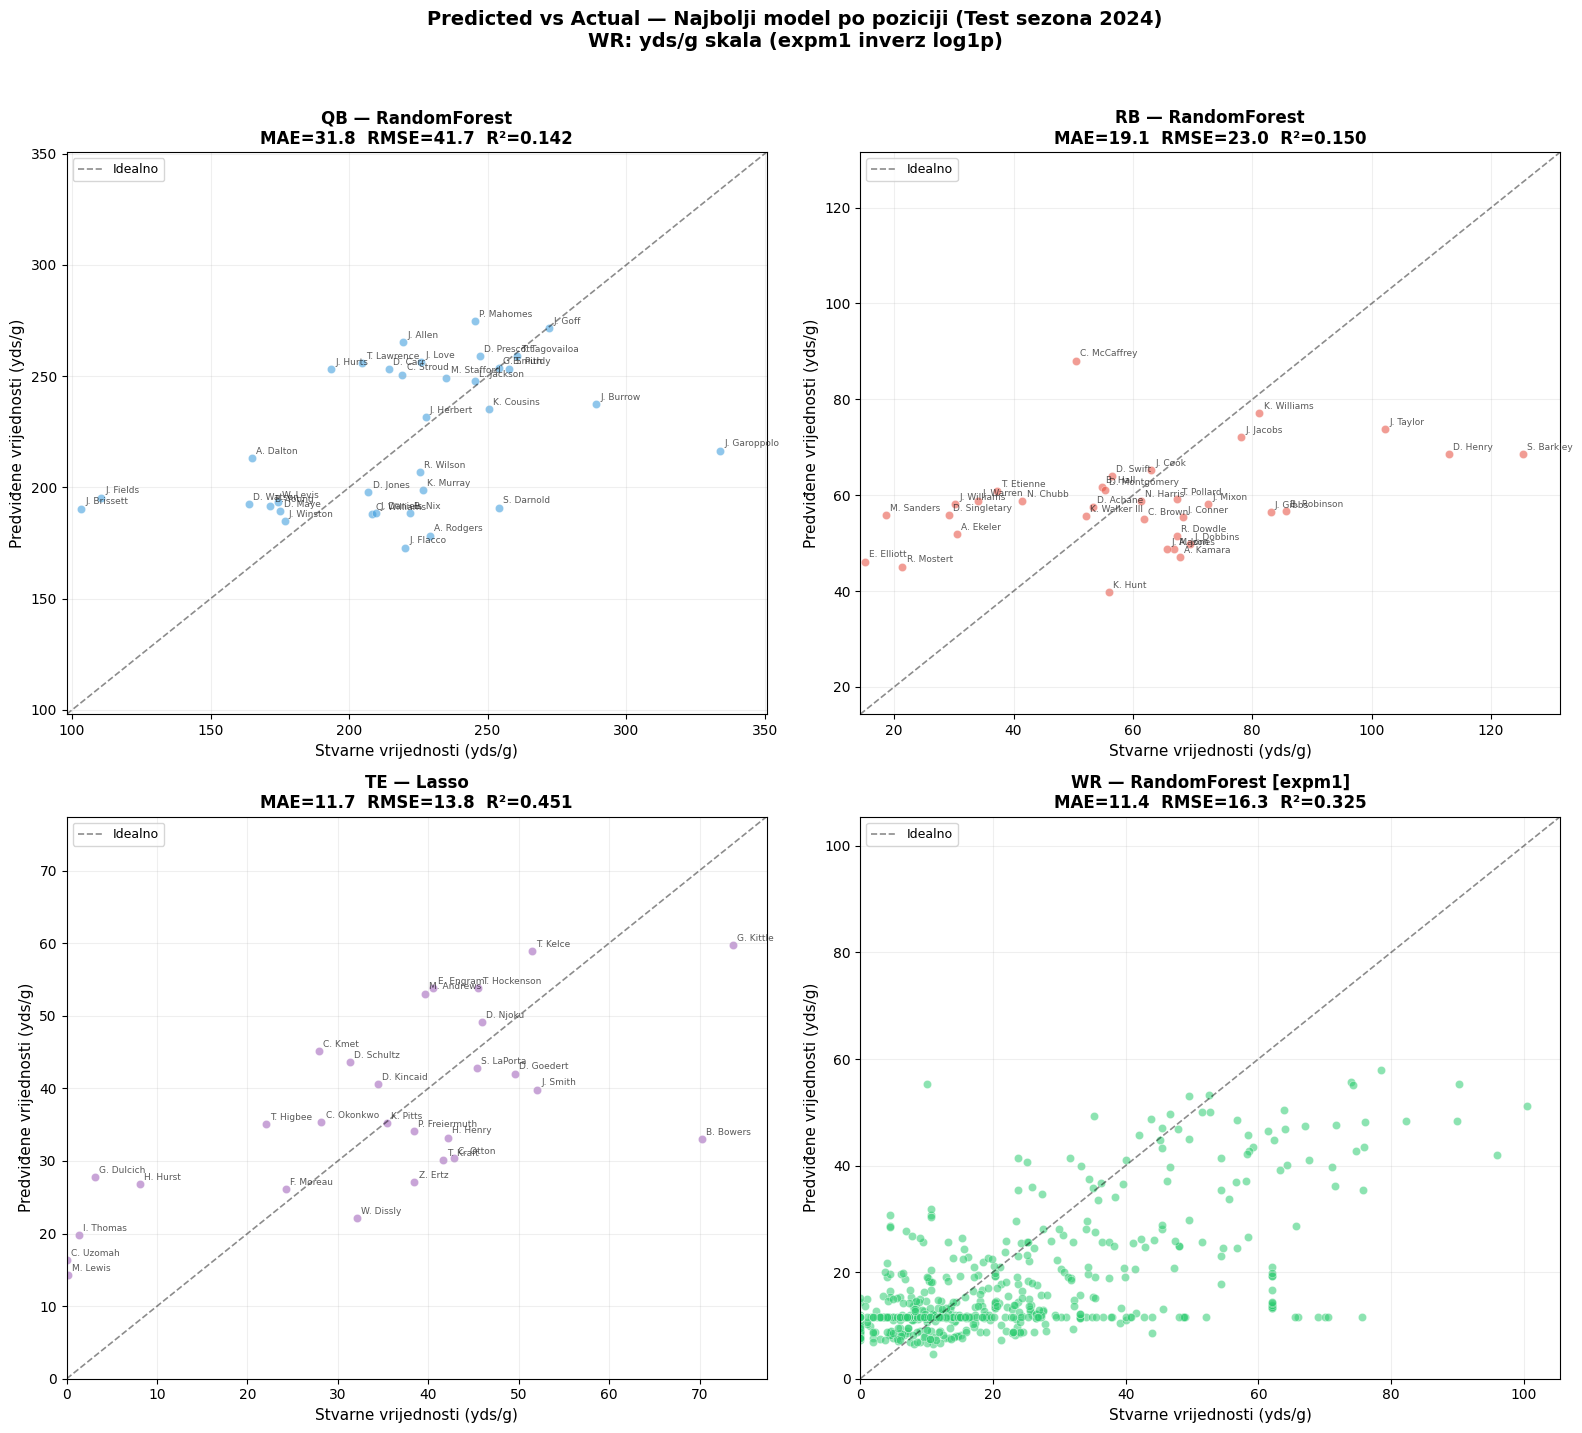

In [15]:
plot_predicted_vs_actual(
    processed, best_models, test_results, lagged,
    test_year=2024,
    annotate_positions=('QB', 'RB', 'TE'),
)


### Analiza dobijenih rezultata

Rezultati dobijeni  potvrđuju da se performanse modela značajno razlikuju po pozicijama, ali i da nelinearni modeli u većini slučajeva ostvaruju blagu prednost.

Kod QB pozicije najbolji rezultat postiže XGBoost ($R^2 = 0.145$), uz vrlo slične performanse RandomForest-a ($R^2 = 0.142$) i LightGBM-a ($R^2 = 0.138$). Ovo potvrđuje da je za kvoterbekove prisutna određena nelinearna struktura u podacima, koju stabla odlučivanja uspešnije hvataju od linearnih modela. Ipak, ukupna objašnjena varijansa ostaje niska (oko 14%), što znači da modeli objašnjavaju relativno mali deo realnog učinka QB igrača. Posebno je primetno da LinearRegression, Ridge i ElasticNet imaju negativan $R^2$, što implicira da su lošiji od jednostavne predikcije prosekom.

Kod RB pozicije najbolji model je RandomForest ($R^2 = 0.150$), dok su XGBoost i LightGBM nešto slabiji, ali i dalje konkurentni. Linearni modeli ovde postižu skromne rezultate (maksimalno oko $R^2 = 0.118$), što ponovo sugeriše prisustvo kompleksnih interakcija među atributima. Ipak, kao i kod QB pozicije, ukupna predvidljivost ostaje ograničena, jer modeli objašnjavaju svega oko 15% varijanse performansi.

Pozicija TE se jasno izdvaja kao najpredvidljivija u celom skupu podataka. Najbolji rezultat postiže Lasso regresija ($R^2 = 0.451$), što je ujedno i najviša vrednost determinacije među svim pozicijama. Blizu su i LightGBM ($R^2 = 0.420$) i XGBoost ($R^2 = 0.404$), ali linearni model sa regularizacijom ipak daje najbolju generalizaciju. Ovo ukazuje da su ključni faktori performansi kod TE pozicije u izraženijoj linearnoj korelaciji, dok Lasso dodatno doprinosi eliminacijom manje značajnih varijabli i smanjenjem overfitting-a.

Kod WR pozicije najbolji rezultat ostvaruje RandomForest ($R^2 = 0.325$), dok su LightGBM ($R^2 = 0.315$) i XGBoost ($R^2 = 0.313$) vrlo blizu. Ovde je primetno da i KNN model daje solidan rezultat ($R^2 = 0.279$), što sugeriše postojanje lokalnih obrazaca u podacima. Iako su rezultati bolji nego kod QB i RB pozicija, objašnjena varijansa je i dalje umerenog nivoa (oko 30%), što znači da značajan deo performansi i dalje zavisi od faktora koji nisu uključeni u model.

Generalno posmatrano, nelinearni ansambl modeli (RandomForest, XGBoost, LightGBM) dominiraju kod QB, RB i WR pozicija, dok se kod TE pozicije linearni model sa L1 regularizacijom pokazuje kao optimalno rešenje. Ipak, vrednosti $R^2$ za QB i RB ostaju relativno niske, što potvrđuje da su ove pozicije najteže za precizno modelovanje, verovatno zbog izražene zavisnosti od spoljašnjih faktora koji nisu u potpunosti obuhvaćeni dostupnim atributima.

### Kalibracija evaluacije

Kalibracija evaluacije u ovom kontekstu odnosi se na primenu walk-forward validacije (cross-year hold-out) kako bi se simulirali realni uslovi predikcije performansi NFL igrača, gde modeli treniraju isključivo na istorijskim podacima bez curenja informacija iz budućih sezona. Umesto jednog splita (trening pre 2024, test na 2024), koriste se više foldova: trening do 2020 za test na 2021, do 2021 za 2022, itd., sve do 2024, što omogućava evaluaciju stabilnosti modela preko vremena, identifikaciju eventualnih trendova u performansama i bolju procenu generalizacije na neviđene podatke, izbegavajući optimizam jednokratne evaluacije.

In [16]:
FOLDS = [
    {'name': 'Fold 1', 'train_end': 2020, 'test_year': 2021},
    {'name': 'Fold 2', 'train_end': 2021, 'test_year': 2022},
    {'name': 'Fold 3', 'train_end': 2022, 'test_year': 2023},
    {'name': 'Fold 4', 'train_end': 2023, 'test_year': 2024},
]

POS_SCOL    = {'QB': 'Season', 'RB': 'Season', 'TE': 'Season', 'WR': 'season'}
POS_ID_COLS = {
    'QB': ['Player', 'Season', 'Team'],
    'RB': ['Player', 'Season', 'Team'],
    'TE': ['Player', 'Season', 'Team'],
    'WR': ['receiver_player_name', 'season', 'posteam'],
}

CAL_MODEL_CONFIGS = MODEL_CONFIGS  

cal_records      = []
cal_best_per_pos = {}
cal_best_params  = {}

for pos in ['QB', 'RB', 'TE', 'WR']:
    scol      = POS_SCOL[pos]
    id_cols   = POS_ID_COLS[pos]
    df_full   = lagged[pos]
    is_wr     = (pos == 'WR')
    feat_cols = [c for c in df_full.columns if c not in id_cols + ['target']]

    print(f'\n{"═"*90}')
    print(f'  {pos} — Kalibracija evaluacije (Cross-Year Hold-Out)')
    if is_wr:
        print(f'  [WR: sve metrike na originalnoj yds/g skali — expm1 inverz]')
    print(f'{"═"*90}')

    model_avg_rmse = {}

    for model_name, mcfg in CAL_MODEL_CONFIGS.items():
        fold_mae, fold_rmse, fold_r2 = [], [], []

        for fold in FOLDS:
            tr_df, te_df, X_tr, X_te, y_tr, y_te = prepare_fold_data(
                df_full, scol, feat_cols, fold['train_end'], fold['test_year']
            )
            if tr_df is None:
                continue

            X_tr_i, X_te_i = impute_lag2_and_median(X_tr, X_te)

            X_tr_s, X_te_s = scale_fold(X_tr_i, X_te_i, BINARY_COLS)

            best_model, best_p = fit_fold_model(mcfg, X_tr_s, y_tr, len(X_tr_s))

            mae, rmse, r2, _ = evaluate_fold(best_model, X_te_s, y_te, is_wr)

            fold_mae.append(mae)
            fold_rmse.append(rmse)
            fold_r2.append(r2)

            cal_records.append(dict(
                pos=pos, model=model_name,
                fold=fold['name'], train_end=fold['train_end'], test_year=fold['test_year'],
                n_train=len(tr_df), n_test=len(te_df),
                mae=mae, rmse=rmse, r2=r2,
                best_params=str(best_p),
            ))
            cal_best_params[(pos, model_name, fold['name'])] = best_p

        avg_rmse = np.mean(fold_rmse) if fold_rmse else np.nan
        model_avg_rmse[model_name] = avg_rmse

    best_model_name = print_position_results(
        pos, cal_records, CAL_MODEL_CONFIGS, FOLDS, model_avg_rmse, cal_best_params
    )
    cal_best_per_pos[pos] = best_model_name

cal_df = pd.DataFrame(cal_records)



══════════════════════════════════════════════════════════════════════════════════════════
  QB — Kalibracija evaluacije (Cross-Year Hold-Out)
══════════════════════════════════════════════════════════════════════════════════════════

  Model                │       Fold 1 (2021)       Fold 2 (2022)       Fold 3 (2023)       Fold 4 (2024)  │   AvgMAE   AvgRMSE   AvgR²
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  LinearRegression     │    59.87 (R²= 0.233)    35.07 (R²= 0.258)    66.05 (R²= 0.168)    45.81 (R²=-0.038)  │   37.172    51.699   0.155
  Ridge                │    60.49 (R²= 0.217)    36.06 (R²= 0.216)    69.58 (R²= 0.076)    47.89 (R²=-0.134)  │   38.043    53.502   0.094
  Lasso                │    59.74 (R²= 0.237)    34.72 (R²= 0.273)    69.53 (R²= 0.078)    44.48 (R²= 0.021)  │   37.141    52.119   0.152
  ElasticNet           │    60.11 (R²= 0.227)    36.07 (R²= 0.216)    69.22 (R²

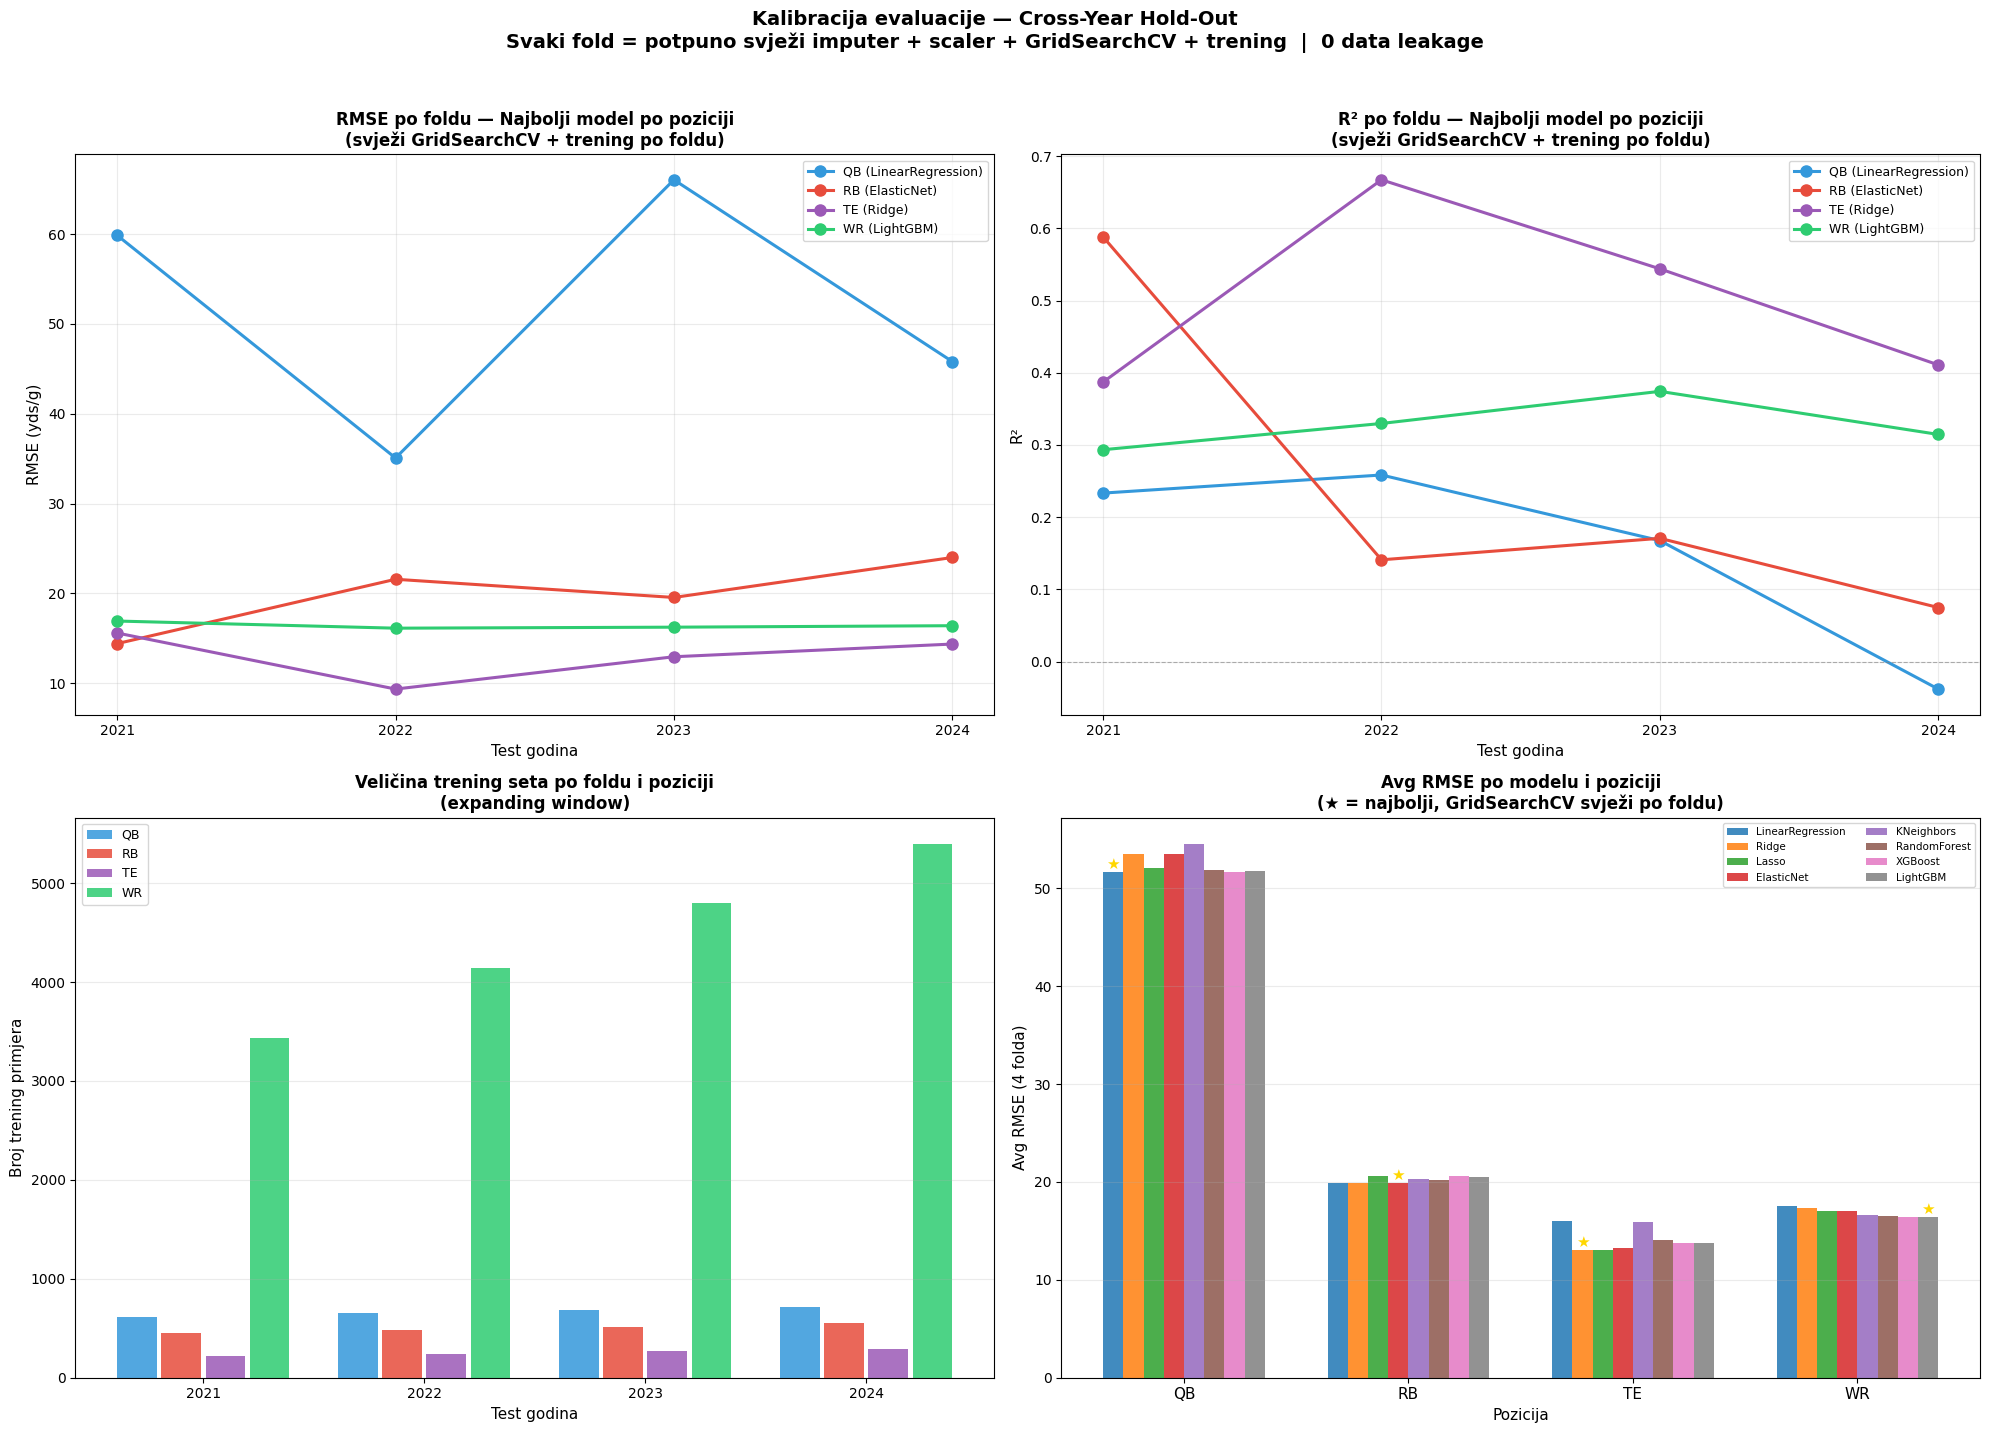


═══════════════════════════════════════════════════════════════════════════════════════════════
DETALJNI REZULTATI PO POZICIJI I FOLDU (sa parametrima)
═══════════════════════════════════════════════════════════════════════════════════════════════

QB  (★ Najbolji avg RMSE: LinearRegression)
Train/test veličine:   2021: train=617, test=33  2022: train=650, test=31  2023: train=681, test=33  2024: train=714, test=35
                  RMSE_2021  RMSE_2022  RMSE_2023  RMSE_2024  R²_2021  R²_2022  R²_2023  R²_2024  AvgRMSE  AvgR2
model                                                                                                           
ElasticNet            60.11      36.07      69.22      48.60    0.227    0.216    0.086   -0.168   53.501  0.090
KNeighbors            62.57      36.99      74.59      43.85    0.163    0.175   -0.062    0.049   54.499  0.081
Lasso                 59.74      34.72      69.53      44.48    0.237    0.273    0.078    0.021   52.119  0.152
LightGBM       

In [17]:

import matplotlib.pyplot as plt

POSITIONS  = ['QB', 'RB', 'TE', 'WR']
colors_pos = {'QB': '#3498db', 'RB': '#e74c3c', 'TE': '#9b59b6', 'WR': '#2ecc71'}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

plot_rmse_by_fold(axes[0, 0], cal_df, cal_best_per_pos, POSITIONS, colors_pos)
plot_r2_by_fold  (axes[0, 1], cal_df, cal_best_per_pos, POSITIONS, colors_pos)
plot_train_size  (axes[1, 0], cal_df, cal_best_per_pos, POSITIONS, colors_pos)
plot_avg_rmse_bar(axes[1, 1], cal_df, cal_best_per_pos, POSITIONS, CAL_MODEL_CONFIGS, colors_pos)

plt.suptitle('Kalibracija evaluacije — Cross-Year Hold-Out\n'
             'Svaki fold = potpuno svježi imputer + scaler + GridSearchCV + trening  |  0 data leakage',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print_calibration_details(cal_df, cal_best_per_pos, cal_best_params, POSITIONS)


QB — treniranje po foldu (RandomForest) ...
  → 132 predikcija prikupljeno (4 folda)
RB — treniranje po foldu (RandomForest) ...
  → 130 predikcija prikupljeno (4 folda)
TE — treniranje po foldu (Lasso) ...
  → 107 predikcija prikupljeno (4 folda)
WR — treniranje po foldu (RandomForest) ...
  → 2515 predikcija prikupljeno (4 folda)


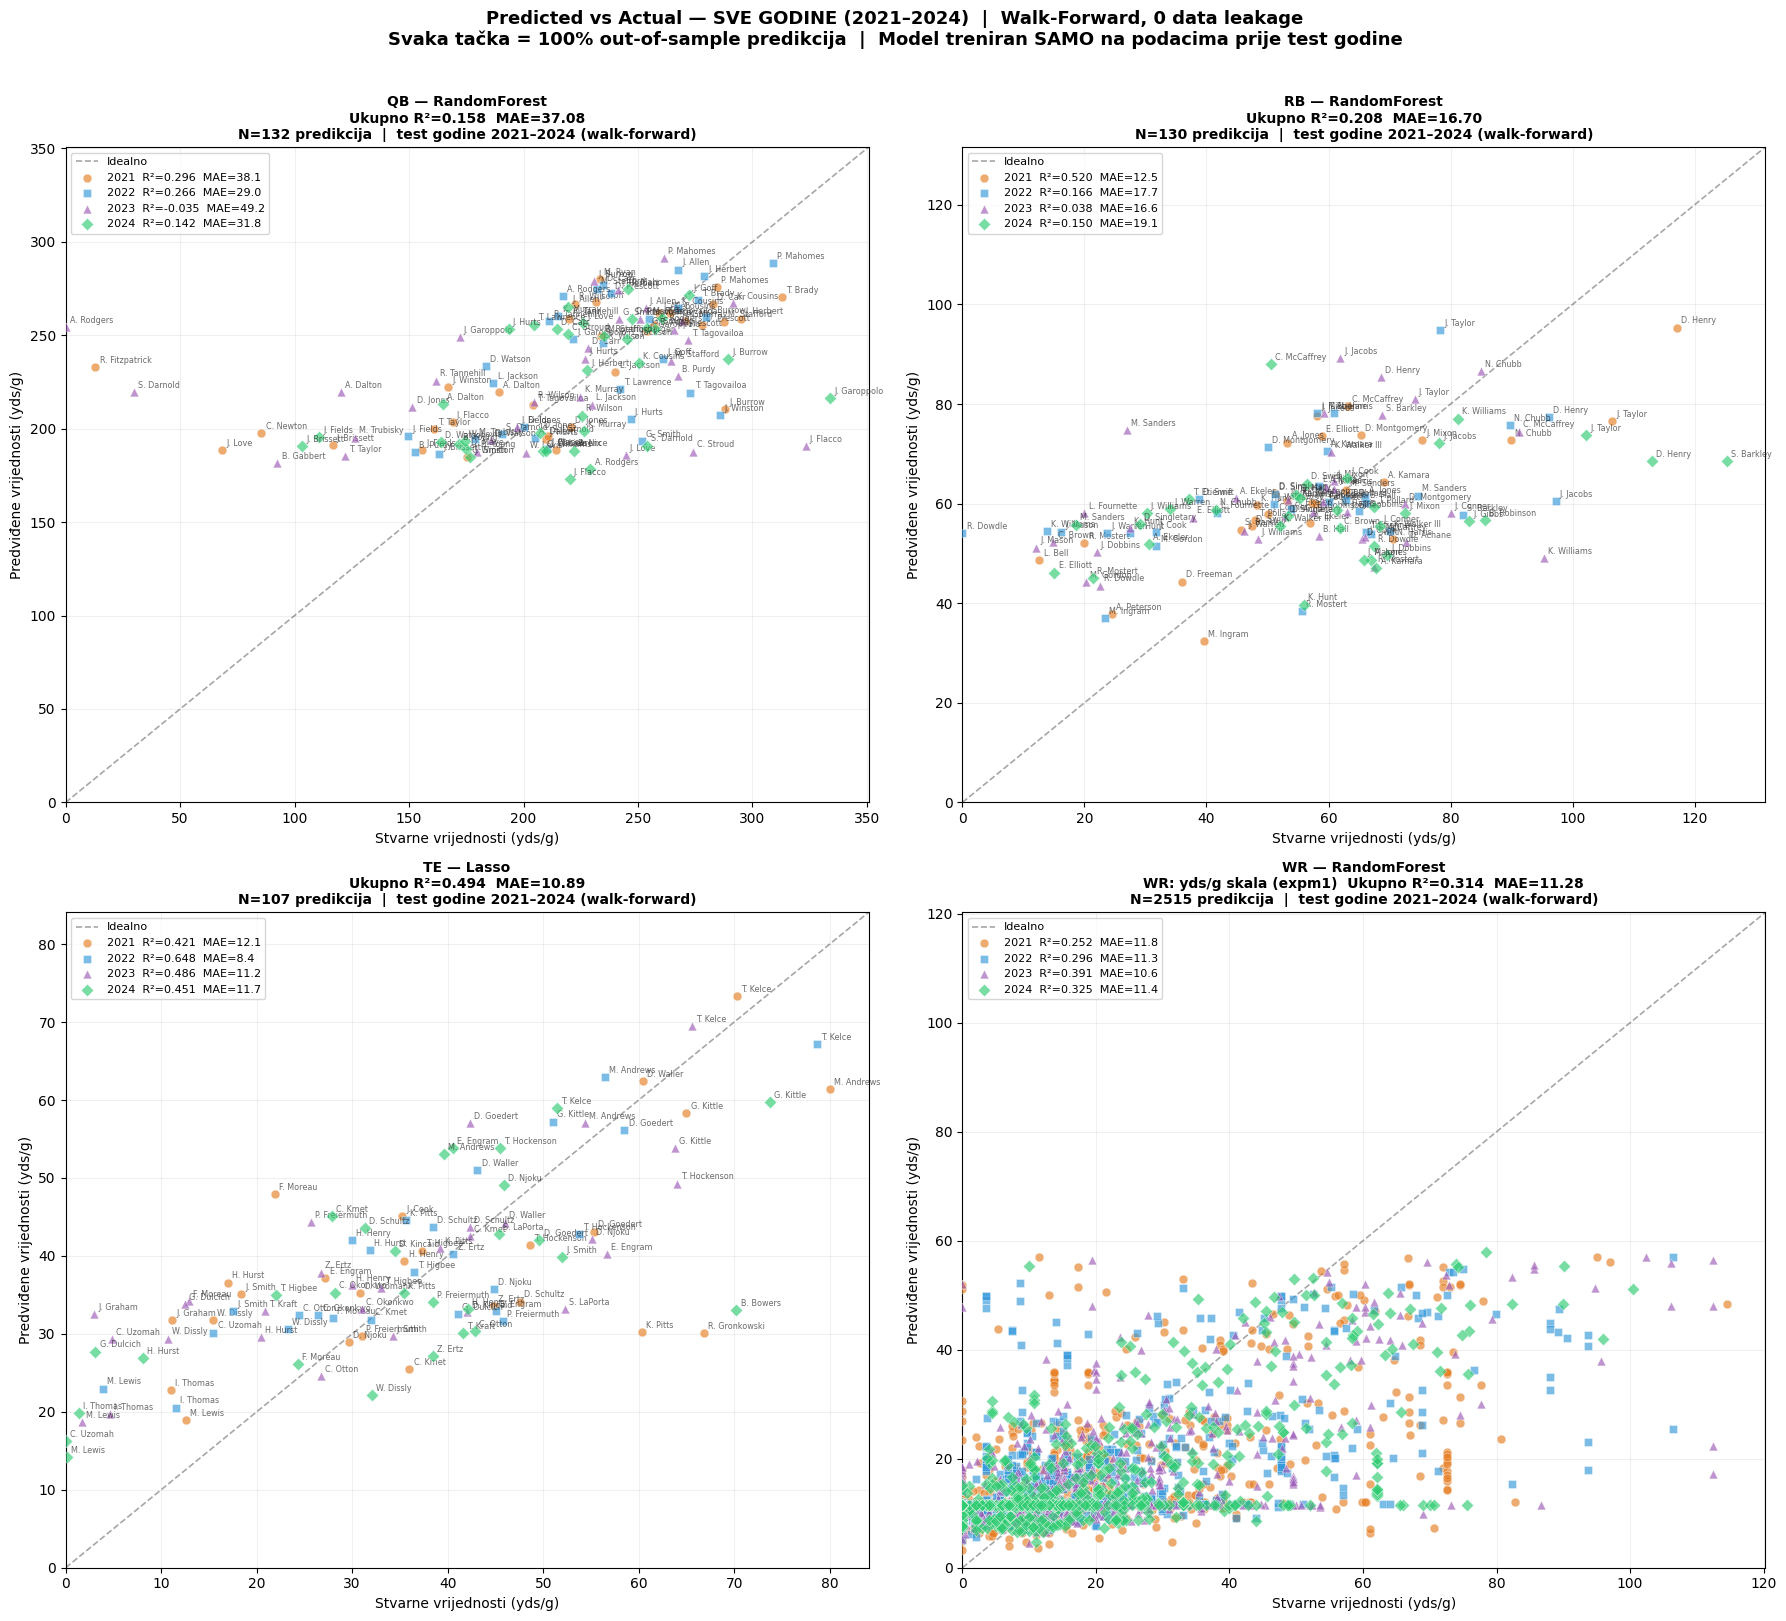


════════════════════════════════════════════════════════════════════
  Pregled metrika po poziciji i test godini (walk-forward)
════════════════════════════════════════════════════════════════════
  Pos    Godina     N       MAE      RMSE       R²
  ──────────────────────────────────────────────────────────
  QB       2021    33    38.118    57.386    0.296
  QB       2022    31    29.032    34.899    0.266
  QB       2023    33    49.188    73.637   -0.035
  QB       2024    35    31.817    41.650    0.142
  QB        AVG   132    37.081    54.082    0.158
  ──────────────────────────────────────────────────────────
  RB       2021    27    12.511    15.547    0.520
  RB       2022    33    17.701    21.249    0.166
  RB       2023    36    16.640    21.048    0.038
  RB       2024    34    19.114    23.000    0.150
  RB        AVG   130    16.699    20.636    0.208
  ──────────────────────────────────────────────────────────
  TE       2021    25    12.109    15.149    0.421
  TE   

In [18]:
all_preds = plot_walkforward_predicted_vs_actual(
    best_models        = best_models,
    lagged             = lagged,
    pos_id_cols        = POS_ID_COLS,
    binary_cols        = BINARY_COLS,
    cal_model_configs  = CAL_MODEL_CONFIGS,
    cal_best_params    = cal_best_params,
    positions          = ['QB', 'RB', 'TE', 'WR'],
    annotate_positions = ('QB', 'RB', 'TE'),
)


Rezultati dobijeni kroz rolling expanding window evaluaciju (trening do 2020, test 2021, zatim progresivno do 2024) potvrđuju stabilnost modela kroz vreme, ali i jasno diferenciraju pozicije po stepenu predvidljivosti.

Kod QB pozicije najbolji prosečan RMSE ostvaruje XGBoost (AvgRMSE = 51.564, AvgR² = 0.176), uz vrlo bliske rezultate LightGBM-a i RandomForest-a. Ipak, vrednosti $R^2$ variraju po sezonama – dok su 2021. i 2022. relativno solidne (oko 0.30), 2023. beleži pad i čak negativne vrednosti kod većine modela. Ovo ukazuje na izraženu nestabilnost i vremensku varijabilnost performansi QB igrača. Linearni modeli (Ridge, ElasticNet, LinearRegression) ne zaostaju drastično u proseku, ali nijedan model ne prelazi prosečnih 18% objašnjene varijanse, što potvrđuje da QB ostaje veoma težak za dugoročno generalizovano modelovanje.

Kod RB pozicije situacija je drugačija – najbolji prosečan rezultat postiže ElasticNet (AvgRMSE = 19.873, AvgR² = 0.244), praktično izjednačen sa Ridge i LinearRegression modelima. Zanimljivo je da ovde linearni modeli nadmašuju ansambl metode, što sugeriše stabilniju i linearniju strukturu odnosa između atributa i ciljne promenljive. Ipak, vidi se izražen pad performansi nakon 2021. (R² sa 0.58 pada na ~0.07–0.17 u narednim sezonama), što može ukazivati na promene u dinamici igre ili distribuciji podataka kroz vreme.

Pozicija TE se ponovo izdvaja kao najpredvidljivija. Najniži prosečan RMSE ima Ridge (AvgRMSE = 13.052, AvgR² = 0.502), gotovo identično kao Lasso. Vrednosti $R^2$ su dosledno visoke (0.41–0.67), posebno u sezonama 2022. i 2023. gde prelaze 0.5. Ovo potvrđuje da su performanse TE igrača u snažnoj i stabilnoj linearnoj korelaciji sa izabranim atributima, dok regularizacija (α=100) doprinosi boljoj generalizaciji kroz različite vremenske foldove. Za razliku od QB i RB, ovde je vremenska stabilnost modela znatno izraženija.

Kod WR pozicije najbolji prosečan rezultat ostvaruje LightGBM (AvgRMSE = 16.414, AvgR² = 0.328), vrlo blizu su XGBoost i RandomForest. $R^2$ vrednosti su umerene (0.29–0.40), sa blagim padom u 2024. godini. Ansambl modeli imaju konzistentnu prednost u odnosu na čisto linearne pristupe, što sugeriše postojanje nelinearnih obrazaca u velikom i heterogenom WR skupu (koji je višestruko veći od ostalih pozicija). Ipak, objašnjena varijansa ostaje oko 30%, što znači da značajan deo performansi i dalje zavisi od faktora koji nisu eksplicitno modelovani.

### 3 NIVOA OPTIMIZACIJA HIPERPARAMETARA

Treći nivo analize uključuje tri komplementarne strategije optimizacije:

1. Random Search - Brzo istražuje veliki prostor parametara, pronalazi regione sa dobrim rezultatima  
2. Grid Search - Finije ispituje najbolje regione iz Random Search-a  
3. Bayesian Optimization - Koristi istorijske rezultate za precizno pronalaženje optimuma

Kombinovanje ove tri strategije omogućava sveobuhvatnu optimizaciju bez preskupih globalnih Grid pretraga.


In [19]:
# Instalacija hyperopt za Bayesian Optimization
import subprocess
import sys

try:
    import optuna
except ImportError:
    print("Instalujem optuna za Bayesian Optimization...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
    import optuna

from sklearn.model_selection import RandomizedSearchCV
import json
from datetime import datetime
sys.path.insert(0, 'modeling')

from modeling.experiment_logger import ExperimentLogger

exp_logger = ExperimentLogger()

Ucitan postojeci log: 1236 eksperimenata


#### NIVO 1: RANDOM SEARCH 



In [20]:
from modeling.hyperparameter_search import run_random_search

random_search_results = run_random_search(
    processed=processed,
    model_configs=MODEL_CONFIGS,
    exp_logger=exp_logger,
    models=['XGBoost', 'LightGBM', 'RandomForest'],
)


QB — Random Search
----------------------------------------------------------------------
  XGBoost              CV MAE=36.789  RMSE=42.054  R²=0.125
  LightGBM             CV MAE=35.915  RMSE=42.152  R²=0.121
  RandomForest         CV MAE=35.919  RMSE=42.105  R²=0.123

RB — Random Search
----------------------------------------------------------------------
  XGBoost              CV MAE=18.335  RMSE=23.742  R²=0.094
  LightGBM             CV MAE=18.709  RMSE=22.819  R²=0.163
  RandomForest         CV MAE=18.172  RMSE=23.303  R²=0.127

TE — Random Search
----------------------------------------------------------------------
  XGBoost              CV MAE=11.695  RMSE=14.878  R²=0.367
  LightGBM             CV MAE=12.092  RMSE=14.250  R²=0.419
  RandomForest         CV MAE=11.892  RMSE=15.032  R²=0.354

WR — Random Search
----------------------------------------------------------------------
  XGBoost              CV MAE=0.693  RMSE=16.172  R²=0.333
  LightGBM             CV MAE=0.688  

#### NIVO 2: GRID SEARCH 

In [21]:
from modeling.hyperparameter_search import run_grid_search

grid_search_results = run_grid_search(
    processed=processed,
    model_configs=MODEL_CONFIGS,
    random_results=random_search_results,
    exp_logger=exp_logger,
)


QB — Grid Search
----------------------------------------------------------------------
  XGBoost              CV MAE=37.030  RMSE=42.484  R²=0.107  (-1.0% vs Random)
  LightGBM             CV MAE=35.836  RMSE=42.245  R²=0.117  (-0.2% vs Random)
  RandomForest         CV MAE=36.898  RMSE=41.837  R²=0.134  (+0.6% vs Random)

RB — Grid Search
----------------------------------------------------------------------
  XGBoost              CV MAE=17.916  RMSE=23.914  R²=0.081  (-0.7% vs Random)
  LightGBM             CV MAE=18.558  RMSE=23.696  R²=0.097  (-3.8% vs Random)
  RandomForest         CV MAE=18.258  RMSE=23.161  R²=0.138  (+0.6% vs Random)

TE — Grid Search
----------------------------------------------------------------------
  XGBoost              CV MAE=11.694  RMSE=14.196  R²=0.424  (+4.6% vs Random)
  LightGBM             CV MAE=12.033  RMSE=14.533  R²=0.396  (-2.0% vs Random)
  RandomForest         CV MAE=11.917  RMSE=14.985  R²=0.358  (+0.3% vs Random)

WR — Grid Search
----

#### NIVO 3: BAYESIAN OPTIMIZATION 

In [22]:
from modeling.hyperparameter_search import run_bayesian_optimization

bayesian_results = run_bayesian_optimization(
    processed=processed,
    model_configs=MODEL_CONFIGS,
    exp_logger=exp_logger,
    models=['XGBoost', 'LightGBM', 'RandomForest'],
    n_trials=15,
)


QB — Bayesian Optimization
----------------------------------------------------------------------
  XGBoost              CV MAE=36.130  RMSE=39.892  R²=0.213  (trials=15)
  LightGBM             CV MAE=35.932  RMSE=40.138  R²=0.203  (trials=15)
  RandomForest         CV MAE=35.840  RMSE=42.103  R²=0.123  (trials=15)

RB — Bayesian Optimization
----------------------------------------------------------------------
  XGBoost              CV MAE=18.327  RMSE=23.783  R²=0.091  (trials=15)
  LightGBM             CV MAE=18.747  RMSE=22.719  R²=0.170  (trials=15)
  RandomForest         CV MAE=18.169  RMSE=23.063  R²=0.145  (trials=15)

TE — Bayesian Optimization
----------------------------------------------------------------------
  XGBoost              CV MAE=11.770  RMSE=14.771  R²=0.376  (trials=15)
  LightGBM             CV MAE=12.098  RMSE=14.268  R²=0.418  (trials=15)
  RandomForest         CV MAE=11.905  RMSE=15.175  R²=0.341  (trials=15)

WR — Bayesian Optimization
------------------

#### Poređenje sve tri strategije optimizacije

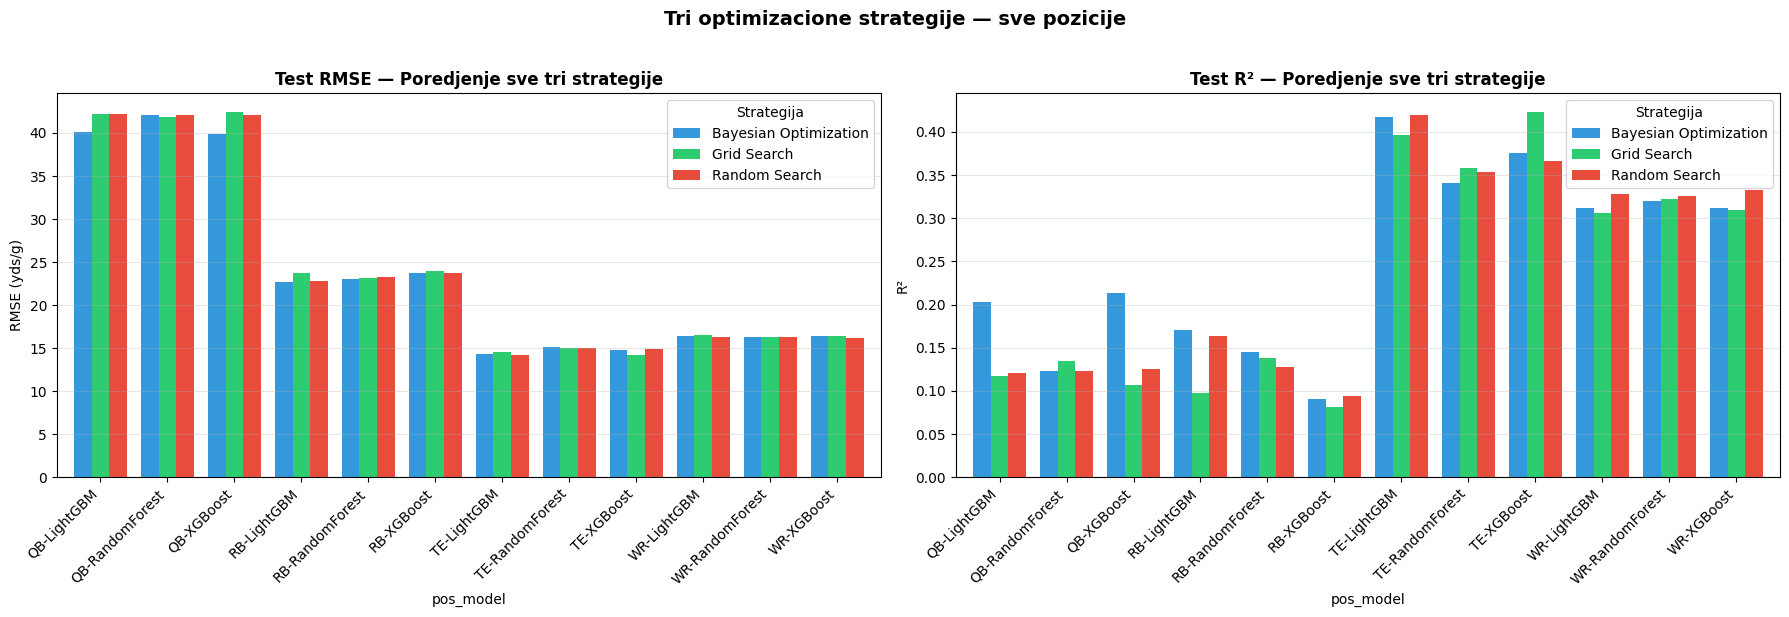


Najbolji model po poziciji:
  QB: XGBoost (Bayesian Optimization) | RMSE=39.892  R²=0.213
  RB: LightGBM (Bayesian Optimization) | RMSE=22.719  R²=0.170
  TE: XGBoost (Grid Search) | RMSE=14.196  R²=0.424
  WR: XGBoost (Random Search) | RMSE=16.172  R²=0.333


,position,model,strategy,test_rmse,test_r2
0,QB,XGBoost,Bayesian Optimization,39.891818,0.212826
1,RB,LightGBM,Bayesian Optimization,22.718846,0.170360
2,TE,XGBoost,Grid Search,14.196382,0.423565
3,WR,XGBoost,Random Search,16.171962,0.333050


In [23]:
from modeling.hyperparameter_search import build_comparison_df, print_best_per_position
from modeling.search_visualization import plot_strategy_comparison

comparison_df = build_comparison_df(random_search_results, grid_search_results, bayesian_results)
plot_strategy_comparison(comparison_df)
print_best_per_position(comparison_df)

#### Tri strategije optimizacije

| Strategija | Prednosti | Vreme | Best za |
|-----------|-----------|-------|---------|
| Random Search | Brzo pronalazi dobre regione, izbegava lokalnih optimuma |  Brzo | Inicijalni pregled |
| Grid Search | Finije ispituje oblast oko bliskog optimuma |  Srednje | Lokalna optimizacija |
| Bayesian | Koristi istoriju prijedloga, najpreciznije |  Sporasnije ali efikasnije | Finalno tuniranje |




QB — dijagnosticki model: LinearRegression

RB — dijagnosticki model: ElasticNet

TE — dijagnosticki model: Ridge

WR — dijagnosticki model: LightGBM


position,model,fold,test_year,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2,diagnosis,best_params
QB,LinearRegression,Fold 1,2021,41.819065,72.231395,59.865727,0.417054,-0.658175,0.233393,Overfit,{}
QB,LinearRegression,Fold 2,2022,42.634508,68.957911,35.070727,0.412068,-0.467902,0.258457,Balanced,{}
QB,LinearRegression,Fold 3,2023,42.210747,64.734671,66.048736,0.411419,-0.307660,0.167600,Overfit,{}
QB,LinearRegression,Fold 4,2024,43.338602,70.628159,45.809055,0.403033,-0.595651,-0.038020,Balanced,{}
RB,ElasticNet,Fold 1,2021,21.686884,23.179395,14.399029,0.357376,0.240804,0.588199,Balanced,"{'alpha': 0.1, 'l1_ratio': 0.1}"
RB,ElasticNet,Fold 2,2022,21.316690,22.705446,21.565014,0.371404,0.257486,0.141006,Balanced,"{'alpha': 0.1, 'l1_ratio': 0.1}"
RB,ElasticNet,Fold 3,2023,21.271185,22.464880,19.538939,0.370027,0.284838,0.170762,Balanced,"{'alpha': 0.1, 'l1_ratio': 0.1}"
RB,ElasticNet,Fold 4,2024,21.154908,22.295994,23.990306,0.367358,0.296143,0.074900,Balanced,"{'alpha': 0.1, 'l1_ratio': 0.1}"
TE,Ridge,Fold 1,2021,14.464871,15.959416,15.581778,0.543712,0.367649,0.387172,Balanced,{'alpha': 100.0}
TE,Ridge,Fold 2,2022,14.467429,15.850894,9.338884,0.537964,0.397051,0.667300,Balanced,{'alpha': 100.0}


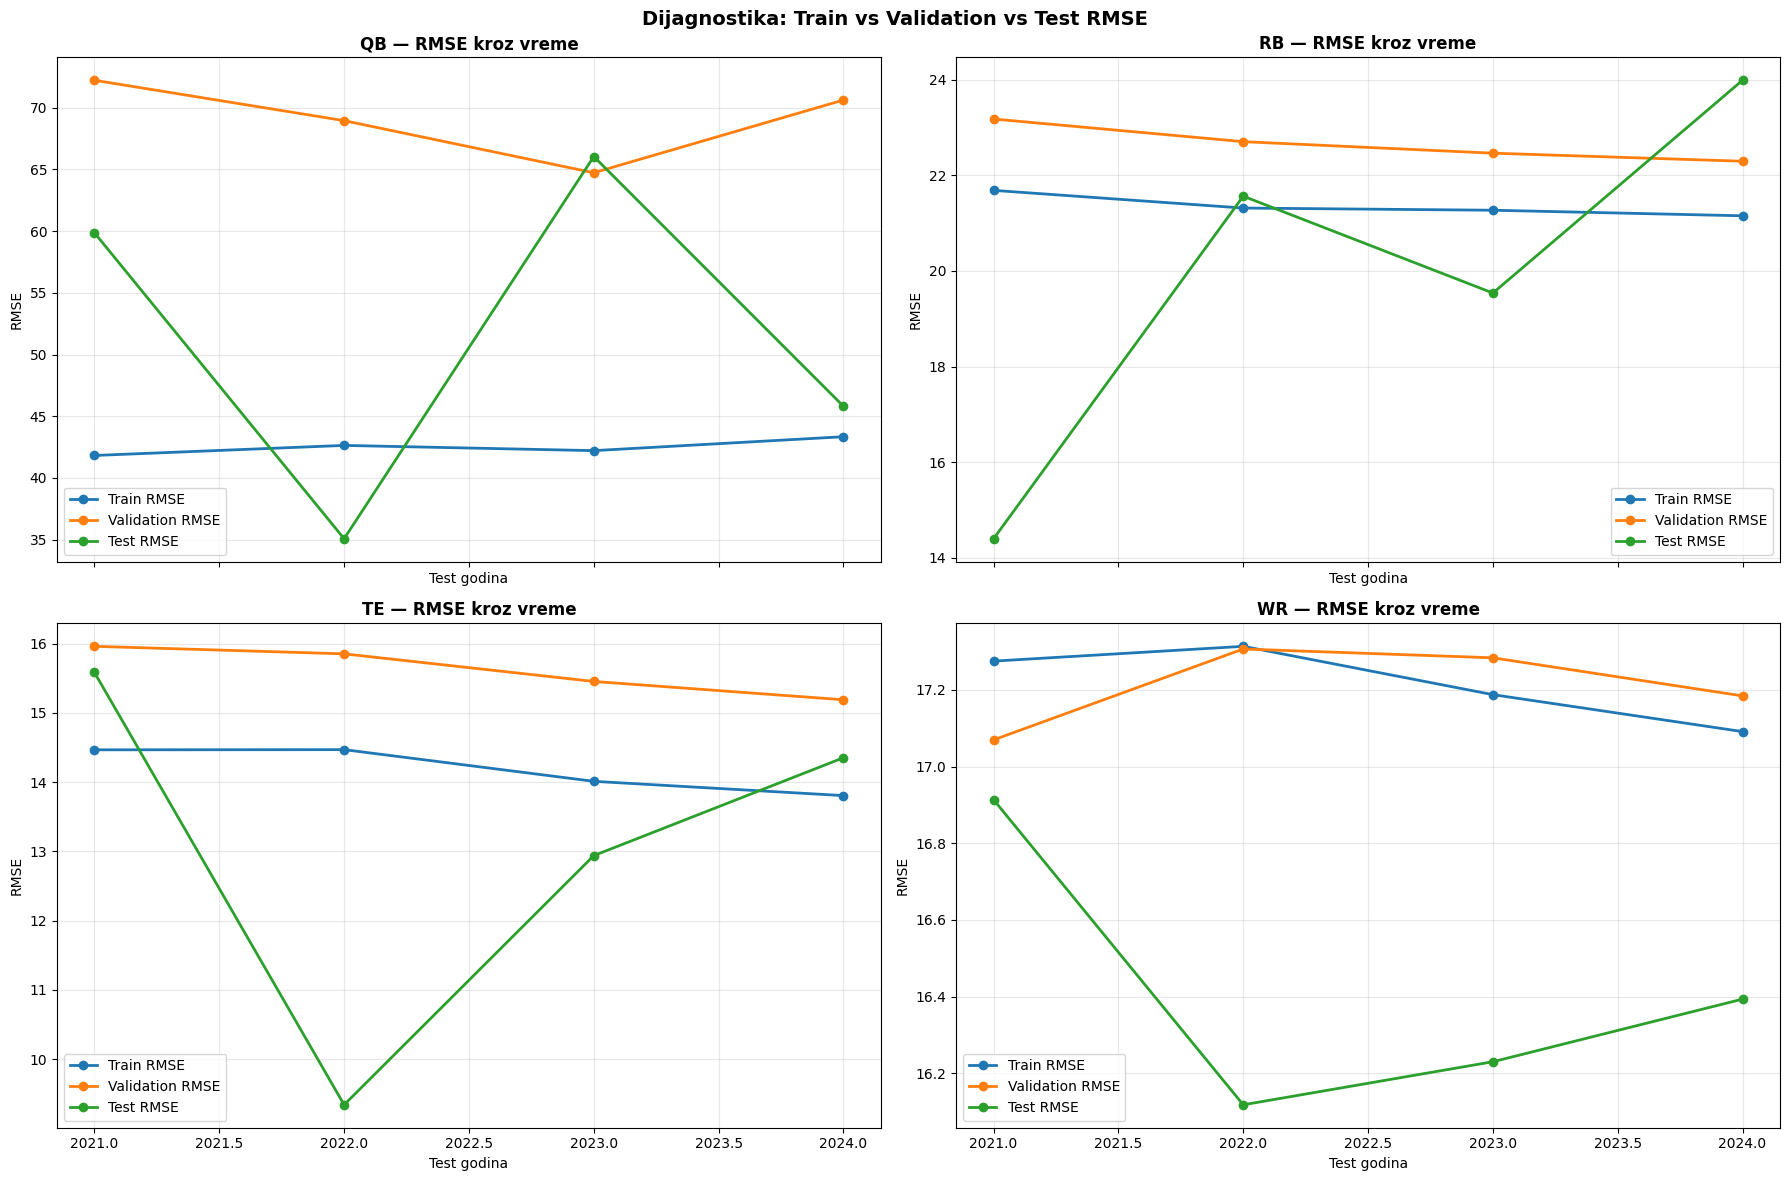

In [24]:
from modeling.diagnostics import run_diagnostics

diag_df = run_diagnostics(
    lagged=lagged,
    processed=processed,
    model_configs=MODEL_CONFIGS,
    folds=FOLDS,
    cal_best_per_pos=cal_best_per_pos,
    pos_scol=POS_SCOL,
    pos_id_cols=POS_ID_COLS,
    prepare_fold_data=prepare_fold_data,
    impute_lag2_and_median=impute_lag2_and_median,
    scale_fold=scale_fold,
    fit_fold_model=fit_fold_model,
    binary_cols=BINARY_COLS,
    cal_model_configs=CAL_MODEL_CONFIGS,
)

In [25]:
from modeling.comparison_table import show_final_comparison

final_comparison_table = show_final_comparison(
    test_results=test_results if 'test_results' in locals() else None,
    random_results=random_search_results if 'random_search_results' in locals() else None,
    grid_results=grid_search_results if 'grid_search_results' in locals() else None,
    bayesian_results=bayesian_results if 'bayesian_results' in locals() else None,
)

,Position,Model,Strategy,MAE,RMSE,R2
0,QB,ElasticNet,Final Test (GridSearchCV),33.966881,48.598723,-0.168296
1,QB,KNeighbors,Final Test (GridSearchCV),33.148358,43.846528,0.049015
2,QB,Lasso,Final Test (GridSearchCV),31.611426,44.483718,0.021175
3,QB,LightGBM,Bayesian Optimization,32.099288,40.138327,0.203067
4,QB,LightGBM,Final Test (GridSearchCV),33.140428,41.746328,0.137936
5,QB,LightGBM,Grid Search,34.493743,42.245224,0.117208
6,QB,LightGBM,Random Search,34.106268,42.151501,0.121121
7,QB,LinearRegression,Final Test (GridSearchCV),34.112653,45.809055,-0.038020
8,QB,RandomForest,Bayesian Optimization,32.637793,42.103378,0.123126
9,QB,RandomForest,Final Test (GridSearchCV),31.816678,41.650167,0.141903



Ukupno redova: 68

Globalno najbolji (najmanji RMSE):
  TE | Lasso | Final Test (GridSearchCV) | MAE=11.707  RMSE=13.850  R2=0.451


### Optimizacija parametara 4 preostala modela

Ove ćelije dopunjuju postojeći 3-nivo pipeline samo za modele:
- KNN
- Ridge
- Lasso
- ElasticNet


In [26]:
from modeling.hyperparameter_search import (
    run_random_search, run_grid_search, run_bayesian_optimization,
    build_comparison_df, print_best_per_position,
 )

EXTRA_MODELS = ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'KNN']

# Dopuna random_search_results za extra modele
extra_random = run_random_search(
    processed=processed,
    model_configs=MODEL_CONFIGS,
    exp_logger=exp_logger,
    models=EXTRA_MODELS,
)
for pos, v in extra_random.items():
    random_search_results.setdefault(pos, {}).update(v)

# Dopuna grid_search_results za extra modele
extra_grid = run_grid_search(
    processed=processed,
    model_configs=MODEL_CONFIGS,
    random_results=random_search_results,
    exp_logger=exp_logger,
    models=EXTRA_MODELS,
)
for pos, v in extra_grid.items():
    grid_search_results.setdefault(pos, {}).update(v)

# Dopuna bayesian_results za extra modele
extra_bayes = run_bayesian_optimization(
    processed=processed,
    model_configs=MODEL_CONFIGS,
    exp_logger=exp_logger,
    models=EXTRA_MODELS,
    n_trials=15,
)
for pos, v in extra_bayes.items():
    bayesian_results.setdefault(pos, {}).update(v)

# Osvezena finalna tabela
from modeling.comparison_table import show_final_comparison
final_comparison_table = show_final_comparison(
    test_results=test_results if 'test_results' in locals() else None,
    random_results=random_search_results,
    grid_results=grid_search_results,
    bayesian_results=bayesian_results,
)

# Dodatni sazetak: potvrda da su sva 3 nivoa optimizacije uradjena za KNN
comparison_df_all = build_comparison_df(
    random_search_results, grid_search_results, bayesian_results
)
print_best_per_position(comparison_df_all)

knn_rows = comparison_df_all[comparison_df_all['model'] == 'KNN'].copy()
if not knn_rows.empty:
    print('\nKNN rezultati kroz sva 3 nivoa optimizacije:')
    print(knn_rows.sort_values(['position', 'strategy']).to_string(index=False))
else:
    print('\nUpozorenje: KNN nije pronadjen u comparison_df_all (proveri MODEL_CONFIGS kljuceve).')


QB — Random Search
----------------------------------------------------------------------
  LinearRegression     CV MAE=45.672  RMSE=45.809  R²=-0.038
  Ridge                CV MAE=35.857  RMSE=49.586  R²=-0.216
  Lasso                CV MAE=36.116  RMSE=45.949  R²=-0.044
  ElasticNet           CV MAE=35.649  RMSE=47.318  R²=-0.108
  KNN                  CV MAE=37.754  RMSE=43.670  R²=0.057

RB — Random Search
----------------------------------------------------------------------
  LinearRegression     CV MAE=19.024  RMSE=23.421  R²=0.118
  Ridge                CV MAE=17.828  RMSE=23.861  R²=0.085
  Lasso                CV MAE=17.814  RMSE=24.221  R²=0.057
  ElasticNet           CV MAE=17.808  RMSE=24.203  R²=0.058
  KNN                  CV MAE=18.619  RMSE=24.058  R²=0.070

TE — Random Search
----------------------------------------------------------------------
  LinearRegression     CV MAE=15.771  RMSE=16.538  R²=0.218
  Ridge                CV MAE=11.832  RMSE=15.146  R²=0.344
  L

,Position,Model,Strategy,MAE,RMSE,R2
0,QB,ElasticNet,Bayesian Optimization,33.555641,47.855475,-0.132834
1,QB,ElasticNet,Final Test (GridSearchCV),33.966881,48.598723,-0.168296
2,QB,ElasticNet,Grid Search,33.175848,47.542029,-0.118043
3,QB,ElasticNet,Random Search,32.927960,47.318466,-0.107553
4,QB,KNN,Bayesian Optimization,32.846411,43.881994,0.047476
5,QB,KNN,Grid Search,30.959727,41.859883,0.133239
6,QB,KNN,Random Search,32.490493,43.669976,0.056658
7,QB,KNeighbors,Final Test (GridSearchCV),33.148358,43.846528,0.049015
8,QB,Lasso,Bayesian Optimization,32.322114,45.214352,-0.011243
9,QB,Lasso,Final Test (GridSearchCV),31.611426,44.483718,0.021175



Ukupno redova: 128

Globalno najbolji (najmanji RMSE):
  TE | Lasso | Final Test (GridSearchCV) | MAE=11.707  RMSE=13.850  R2=0.451

Najbolji model po poziciji:
  QB: XGBoost (Bayesian Optimization) | RMSE=39.892  R²=0.213
  RB: LightGBM (Bayesian Optimization) | RMSE=22.719  R²=0.170
  TE: XGBoost (Grid Search) | RMSE=14.196  R²=0.424
  WR: XGBoost (Random Search) | RMSE=16.172  R²=0.333

KNN rezultati kroz sva 3 nivoa optimizacije:
position model              strategy  test_rmse  test_r2 pos_model
      QB   KNN Bayesian Optimization  43.881994 0.047476    QB-KNN
      QB   KNN           Grid Search  41.859883 0.133239    QB-KNN
      QB   KNN         Random Search  43.669976 0.056658    QB-KNN
      RB   KNN Bayesian Optimization  23.031663 0.147356    RB-KNN
      RB   KNN           Grid Search  23.031663 0.147356    RB-KNN
      RB   KNN         Random Search  24.057645 0.069700    RB-KNN
      TE   KNN Bayesian Optimization  17.944920 0.078960    TE-KNN
      TE   KNN           

---
## Multi-output regresija 

Prosirivanje pipeline-a na native multi-output RandomForestRegressor, ciljne varijable se predvidjaju istovremeno:

| Pozicija | Target 1 | Target 2 |
|----------|----------|----------|
| QB | yards_per_game (passing) | attempts_per_game |
| RB | yards_per_game (rushing) | carries_per_game |
| TE | yards_per_game (receiving) | receptions_per_game |
| WR | yards_per_game (receiving) | receptions_per_game |

Iste X matrice kao u postojecem pipeline-u; samo Y se prosiruje na 2 kolone.  

In [27]:
import importlib
import modeling.multi_output_rf as mo_rf

# Osvezi modul da pokupi poslednje izmene na disku
mo_rf = importlib.reload(mo_rf)

MULTI_STAT2_CONFIG = mo_rf.MULTI_STAT2_CONFIG
YARDS_WEIGHT = mo_rf.YARDS_WEIGHT
STAT2_WEIGHT = getattr(mo_rf, 'STAT2_WEIGHT', mo_rf.OTHER_WEIGHT)

RAW_DFS = {'QB': qb, 'RB': rb, 'TE': te, 'WR': wr}

In [28]:
from modeling.multi_output_rf import build_multi_output_splits, MULTI_TARGET_CONFIG

multi_splits = build_multi_output_splits(
    lagged=lagged,
    processed=processed,
    raw_dfs=RAW_DFS,
    test_season=2024,
)

[QB] Y_train shape: (714, 2)  targeti: ['yards_per_game', 'first_downs_per_game']
[RB] Y_train shape: (552, 3)  targeti: ['yards_per_game', 'carries_per_game', 'yards_per_attempt']
[TE] Y_train shape: (295, 4)  targeti: ['yards_per_game', 'receptions_per_game', 'targets_per_game', 'first_downs_per_game']
[WR] Y_train shape: (5393, 5)  targeti: ['yards_per_game', 'receptions_per_game', 'targets_per_game', 'air_yards_per_game', 'yac_per_game']


In [29]:
from modeling.multi_output_rf import train_multi_output_models

best_mo_models, best_mo_params = train_multi_output_models(multi_splits, n_splits=3)
print('\nTrening zavrsen za sve pozicije.')


[QB] GridSearchCV — ['yards_per_game', 'first_downs_per_game']
  X_train: (714, 74)  Y_train: (714, 2)
  Parametri: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}  |  CV MAE: 19.4913

[RB] GridSearchCV — ['yards_per_game', 'carries_per_game', 'yards_per_attempt']
  X_train: (552, 38)  Y_train: (552, 3)
  Parametri: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}  |  CV MAE: 7.4864

[TE] GridSearchCV — ['yards_per_game', 'receptions_per_game', 'targets_per_game', 'first_downs_per_game']
  X_train: (295, 48)  Y_train: (295, 4)
  Parametri: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}  |  CV MAE: 3.7804

[WR] GridSearchCV — ['yards_per_game', 'receptions_per_game', 'targets_per_game', 'air_yards_per_game', 'yac_per_game']
  X_train: (5393, 87)  Y_train: (5393, 5)
  Parametri: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}  |  CV MAE: 4.7064

Trening zavrsen za sve pozicije.


In [30]:
from modeling.multi_output_rf import evaluate_multi_output, YARDS_WEIGHT, OTHER_WEIGHT

metrics_df, eval_detail = evaluate_multi_output(
    best_mo_models, multi_splits,
    yards_weight=YARDS_WEIGHT, other_weight=OTHER_WEIGHT,
)
print('Multi-output evaluacija — test sezona 2024')
print(metrics_df.to_string(index=False))

Multi-output evaluacija — test sezona 2024
position        model               target     MAE    RMSE     R2  weighted_score
      QB RandomForest       yards_per_game 33.6606 42.3498 0.1128         30.3265
      QB RandomForest first_downs_per_game  1.8570  2.2721 0.2590         30.3265
      RB RandomForest       yards_per_game 19.6755 23.3406 0.1243         17.0338
      RB RandomForest     carries_per_game  3.4347  3.9920 0.1599         17.0338
      RB RandomForest    yards_per_attempt  0.5032  0.6439 0.0457         17.0338
      TE RandomForest       yards_per_game 12.6060 15.2772 0.3325         11.1144
      TE RandomForest  receptions_per_game  1.1426  1.4170 0.3354         11.1144
      TE RandomForest     targets_per_game  1.4665  1.8956 0.3493         11.1144
      TE RandomForest first_downs_per_game  0.7300  0.8913 0.3595         11.1144
      WR RandomForest       yards_per_game 11.7257 16.7299 0.2862         13.9898
      WR RandomForest  receptions_per_game  0.8481  1.0

In [31]:
from modeling.multi_output_rf import save_multi_output_results

save_multi_output_results(
    metrics_df=metrics_df,
    eval_detail=eval_detail,
    best_mo_models=best_mo_models,
    best_mo_params=best_mo_params,
)

Rezultati sacuvani: ../results\multi_output_results.csv
  QB: ../models\QB_multi_output_rf.joblib  |  targeti=['yards_per_game', 'first_downs_per_game']  |  ws=30.3265  |  params={'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
  RB: ../models\RB_multi_output_rf.joblib  |  targeti=['yards_per_game', 'carries_per_game', 'yards_per_attempt']  |  ws=17.0338  |  params={'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
  TE: ../models\TE_multi_output_rf.joblib  |  targeti=['yards_per_game', 'receptions_per_game', 'targets_per_game', 'first_downs_per_game']  |  ws=11.1144  |  params={'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
  WR: ../models\WR_multi_output_rf.joblib  |  targeti=['yards_per_game', 'receptions_per_game', 'targets_per_game', 'air_yards_per_game', 'yac_per_game']  |  ws=13.9898  |  params={'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


Grafik sacuvan: ../results/multi_output_pred_vs_actual.png


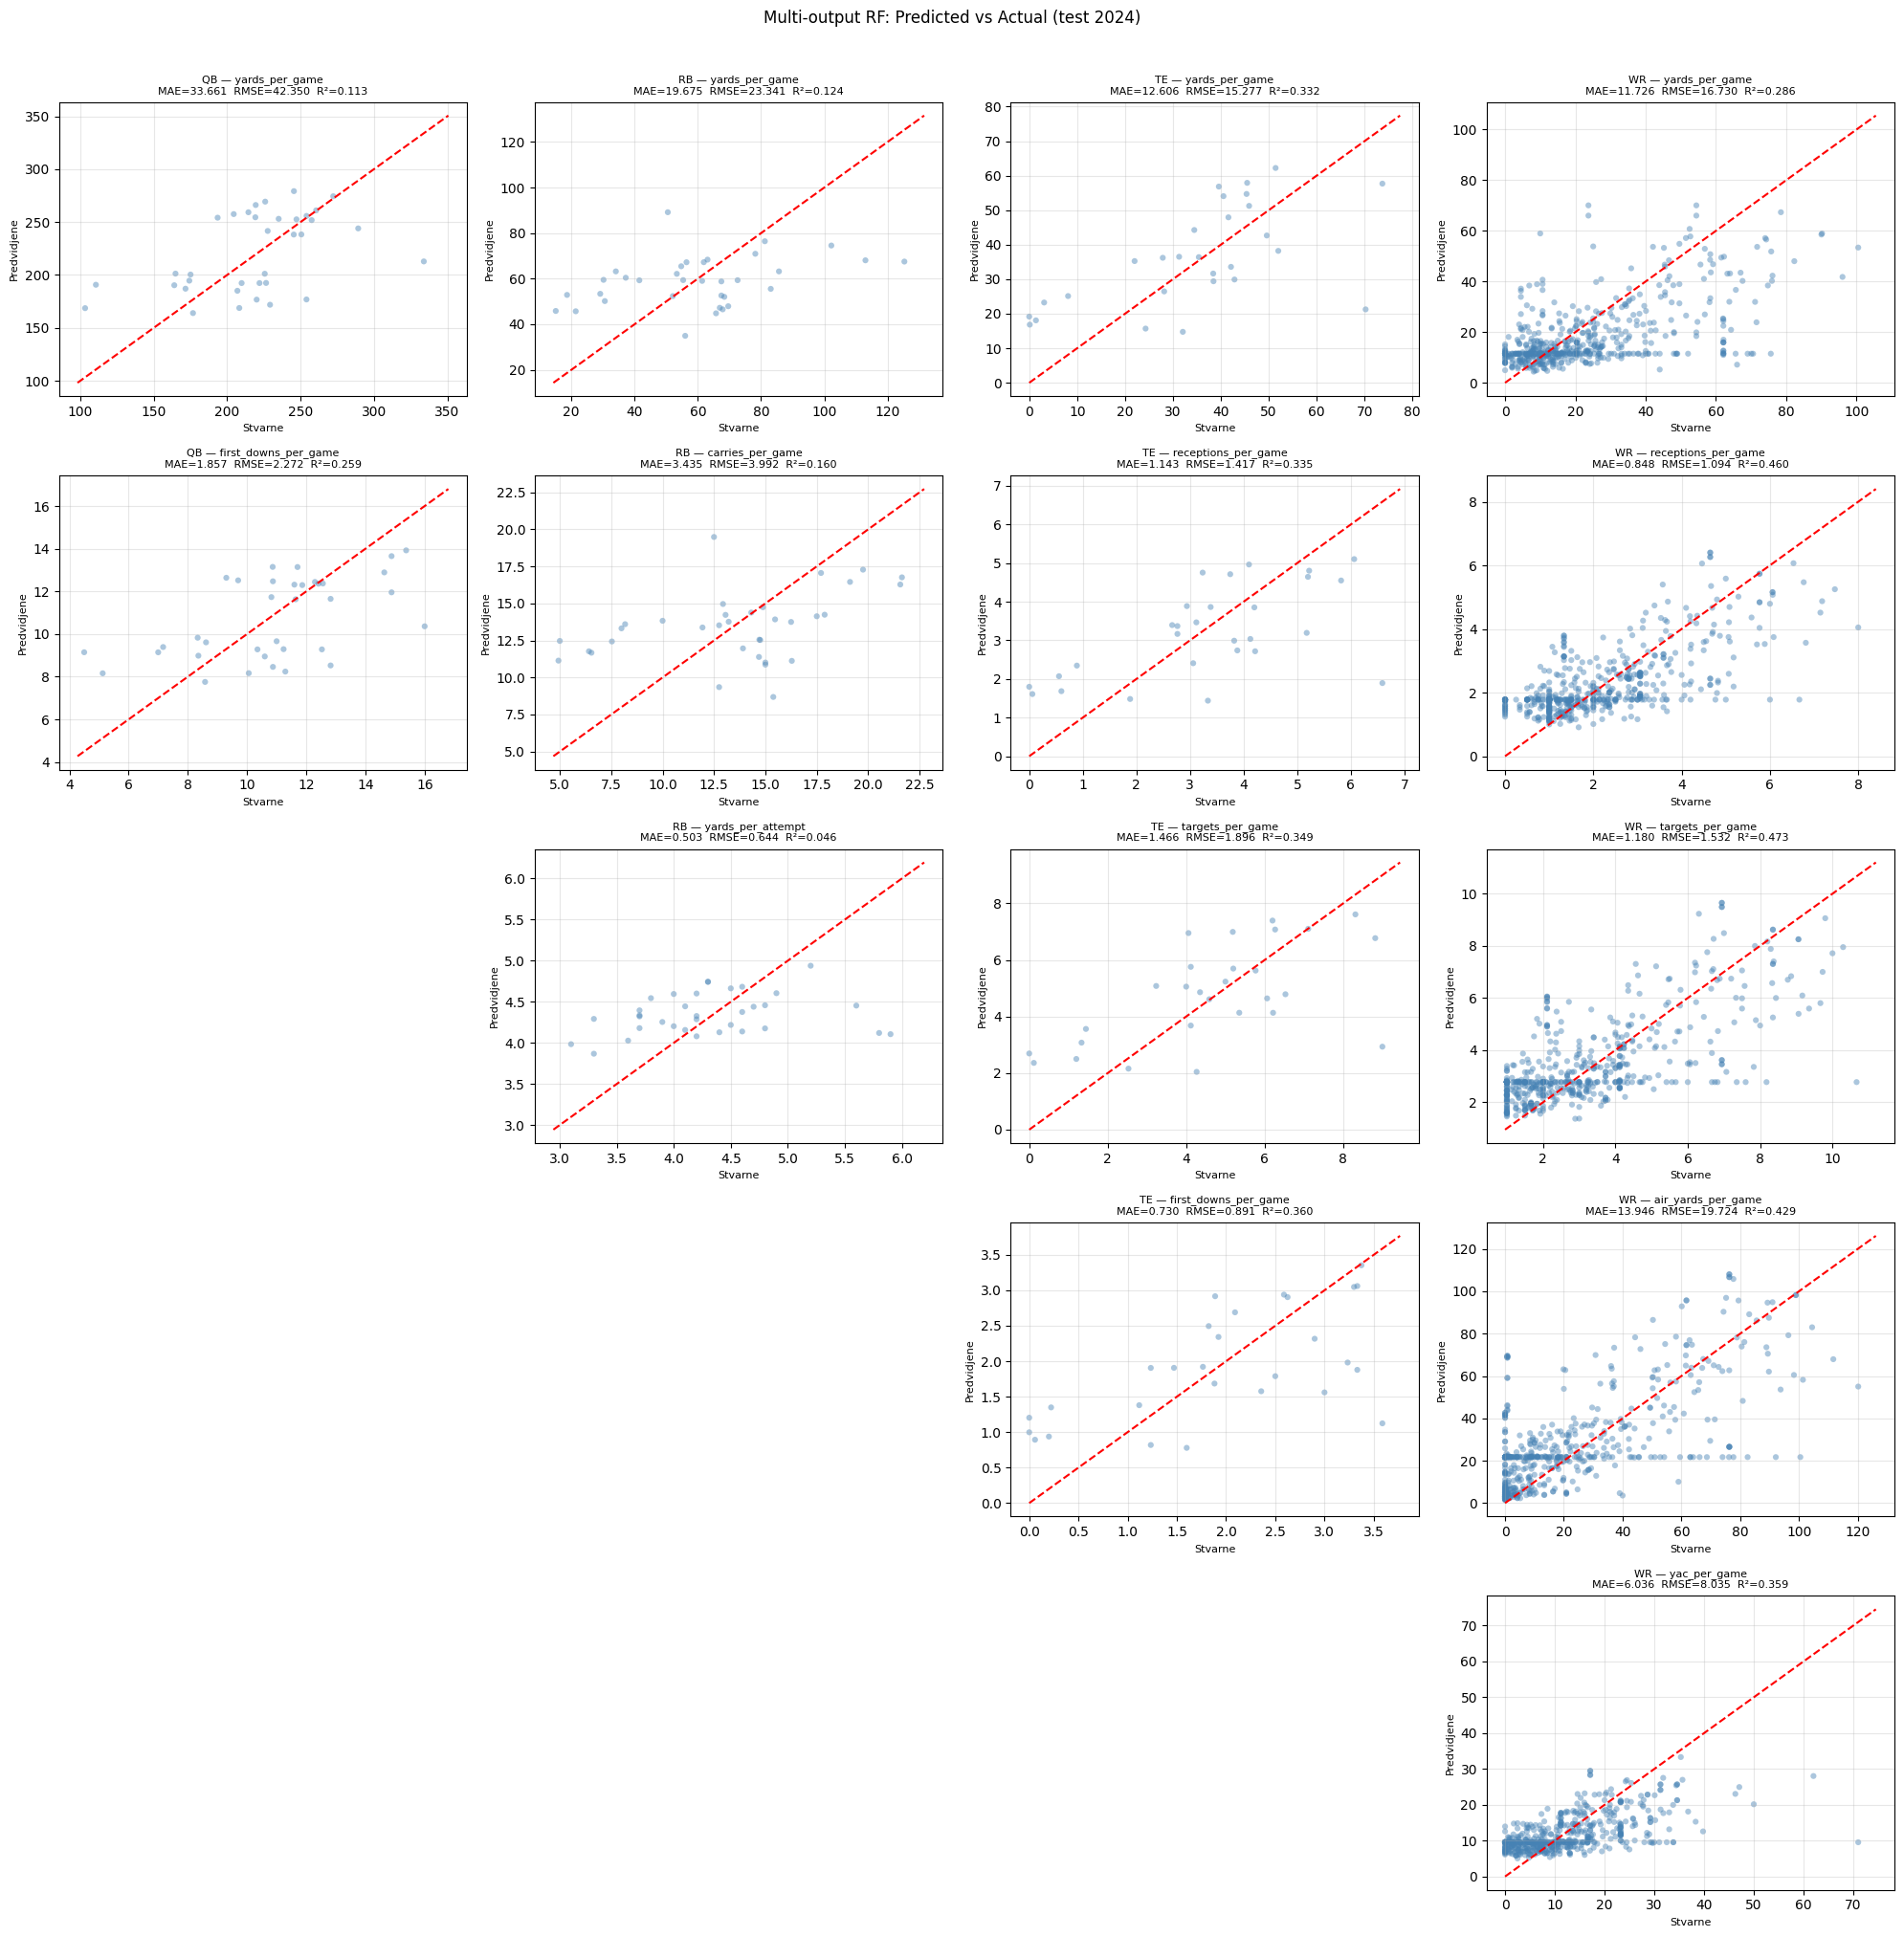

In [32]:
from modeling.multi_output_rf import plot_pred_vs_actual_multi

plot_pred_vs_actual_multi(eval_detail)

In [36]:
from modeling.multi_output_rf import print_multi_output_summary

print_multi_output_summary(eval_detail)

ZAKLJUCAK: Random Forest multi-output regresija

QB:
  yards_per_game            MAE=33.661  RMSE=42.350  R2=0.113 
  first_downs_per_game      MAE=1.857  RMSE=2.272  R2=0.259 

RB:
  yards_per_game            MAE=19.675  RMSE=23.341  R2=0.124 
  carries_per_game          MAE=3.435  RMSE=3.992  R2=0.160 
  yards_per_attempt         MAE=0.503  RMSE=0.644  R2=0.046 

TE:
  yards_per_game            MAE=12.606  RMSE=15.277  R2=0.332 
  receptions_per_game       MAE=1.143  RMSE=1.417  R2=0.335 
  targets_per_game          MAE=1.466  RMSE=1.896  R2=0.349 
  first_downs_per_game      MAE=0.730  RMSE=0.891  R2=0.360 

WR:
  yards_per_game            MAE=11.726  RMSE=16.730  R2=0.286 
  receptions_per_game       MAE=0.848  RMSE=1.094  R2=0.460 
  targets_per_game          MAE=1.180  RMSE=1.532  R2=0.473 
  air_yards_per_game        MAE=13.946  RMSE=19.724  R2=0.429 
  yac_per_game              MAE=6.036  RMSE=8.035  R2=0.359 


### Analiza loss funkcije tokom treninga

Za iterativne modele (XGBoost i LightGBM), prikazujemo kako se loss funkcija (MSE) menja tokom svake iteracije (boosting runde). Ovo nam omogućava da vidimo da li model konvergira, da li ima overfitting (train loss opada ali test loss raste), itd.

Za neiterativne modele (LinearRegression, Ridge, Lasso, ElasticNet, KNN, RandomForest), koji nemaju iterativni trening proces, prikazujemo poređenje train vs test loss-a kao agregatne vrednosti.

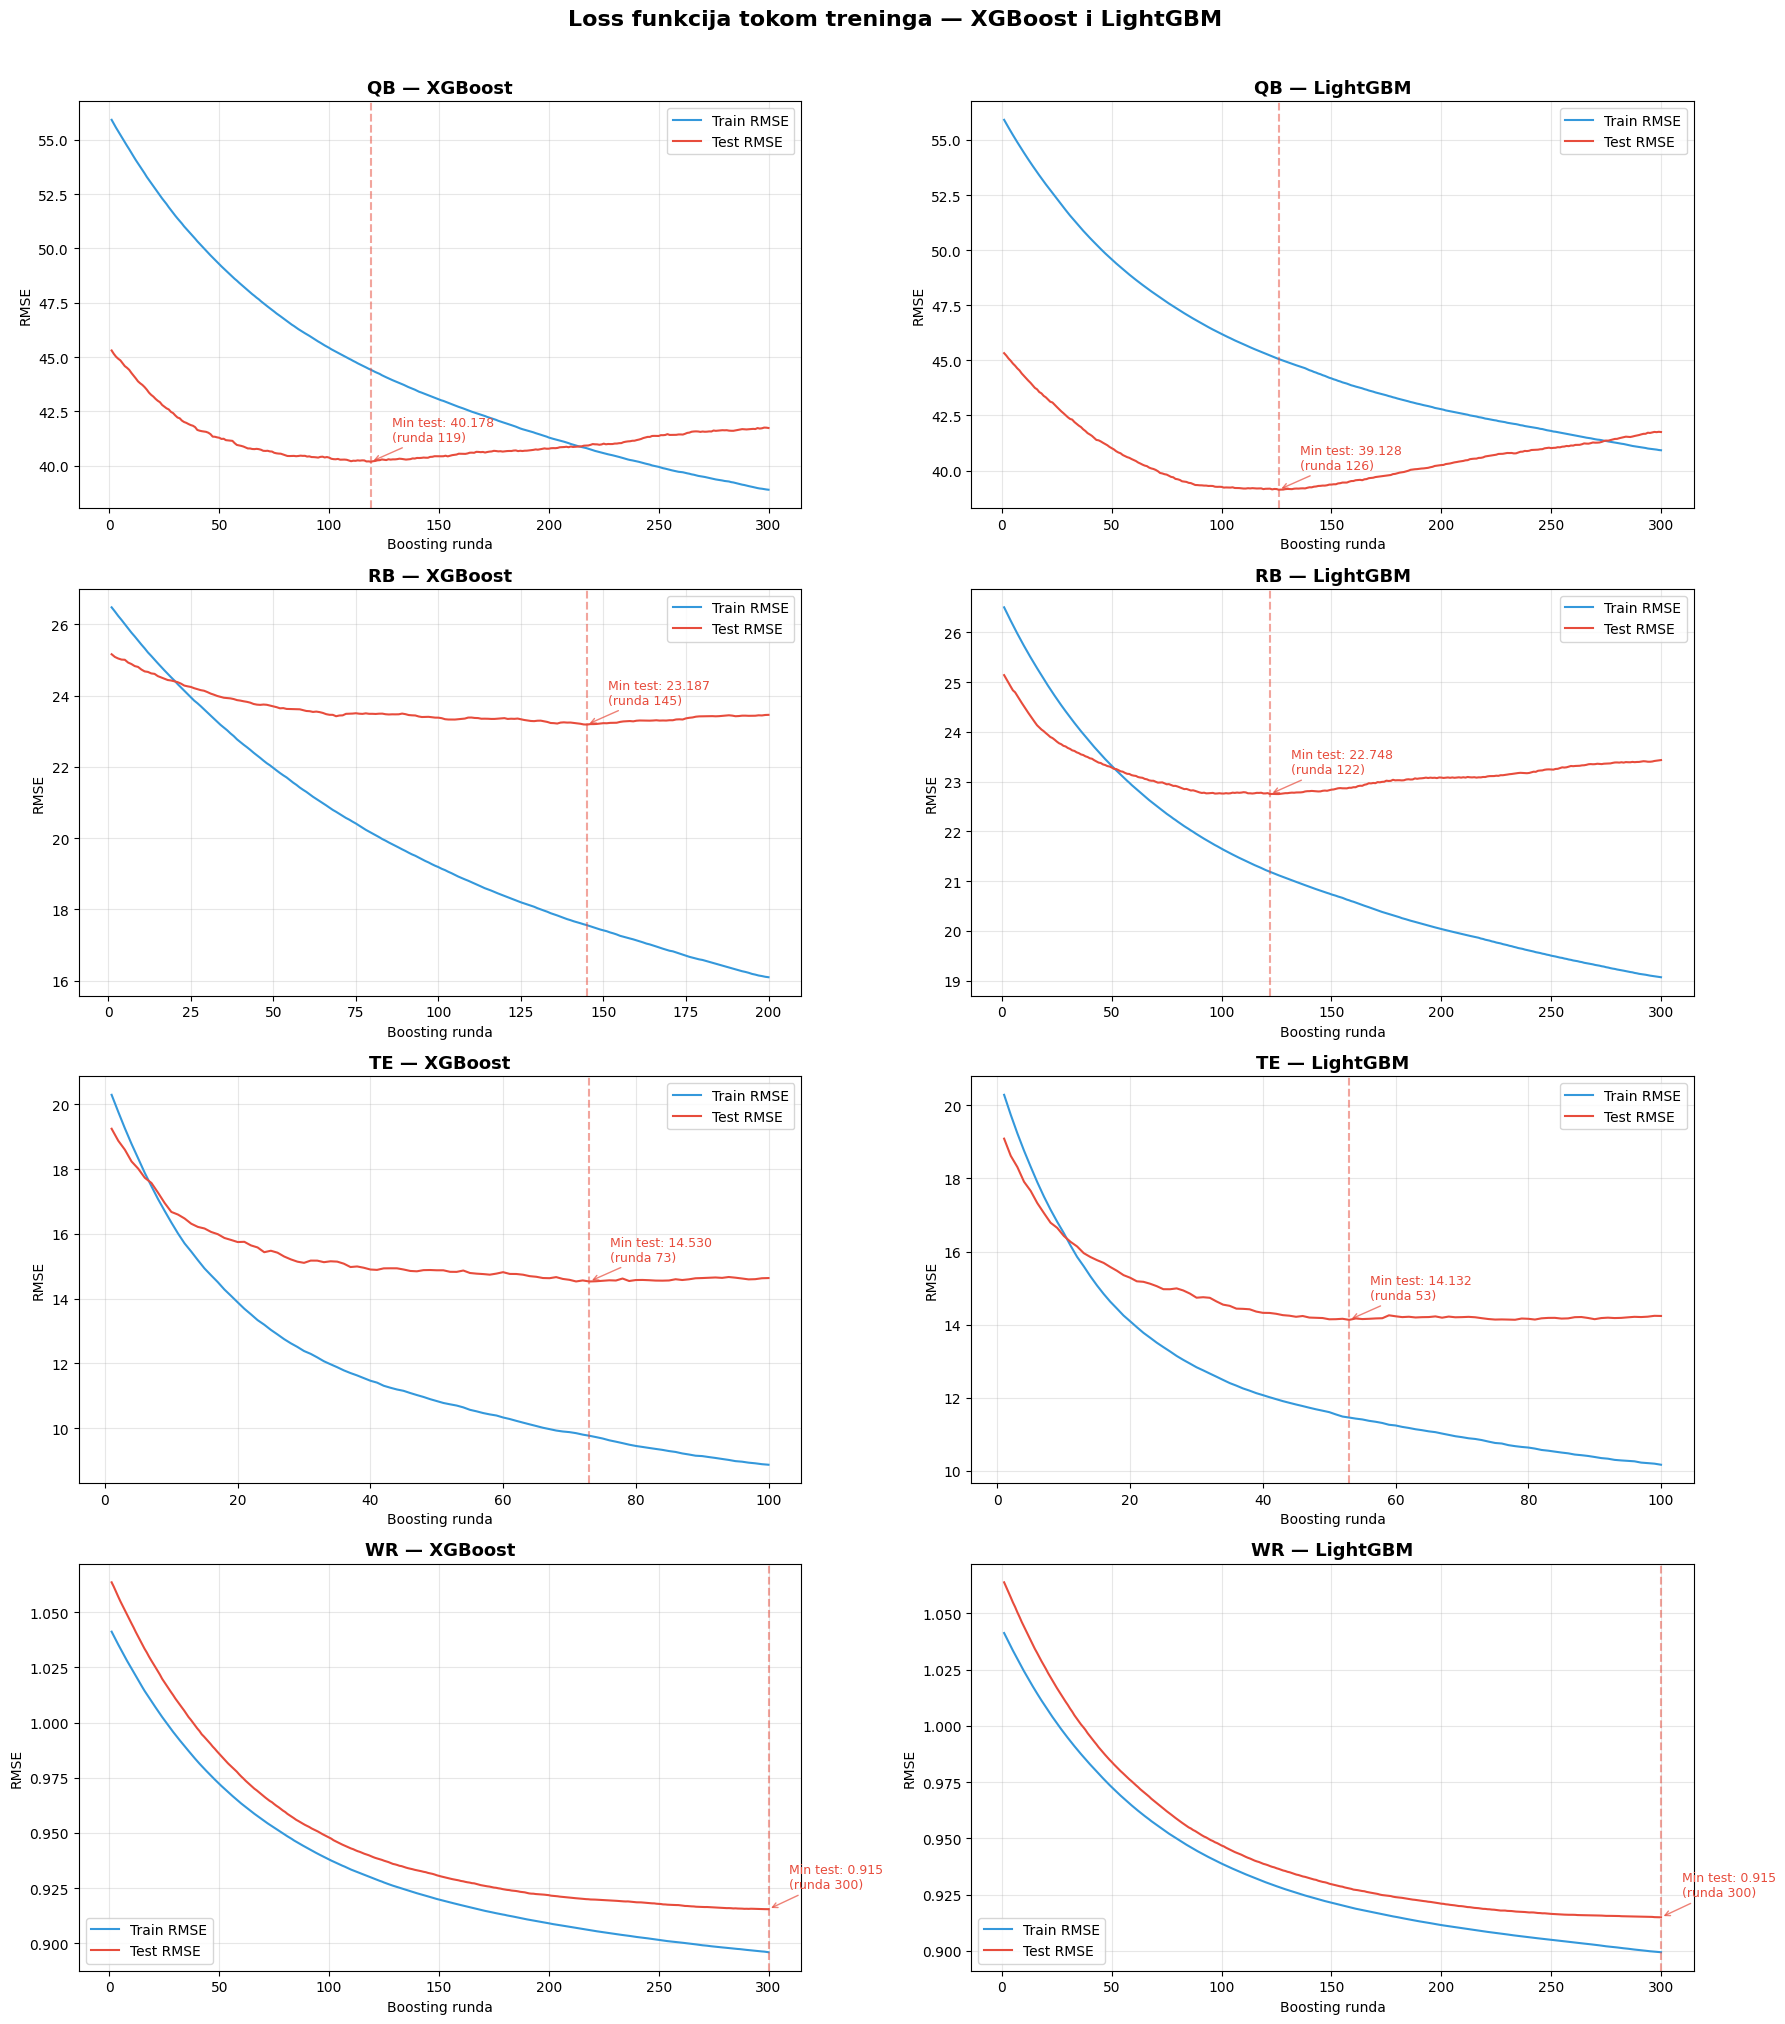

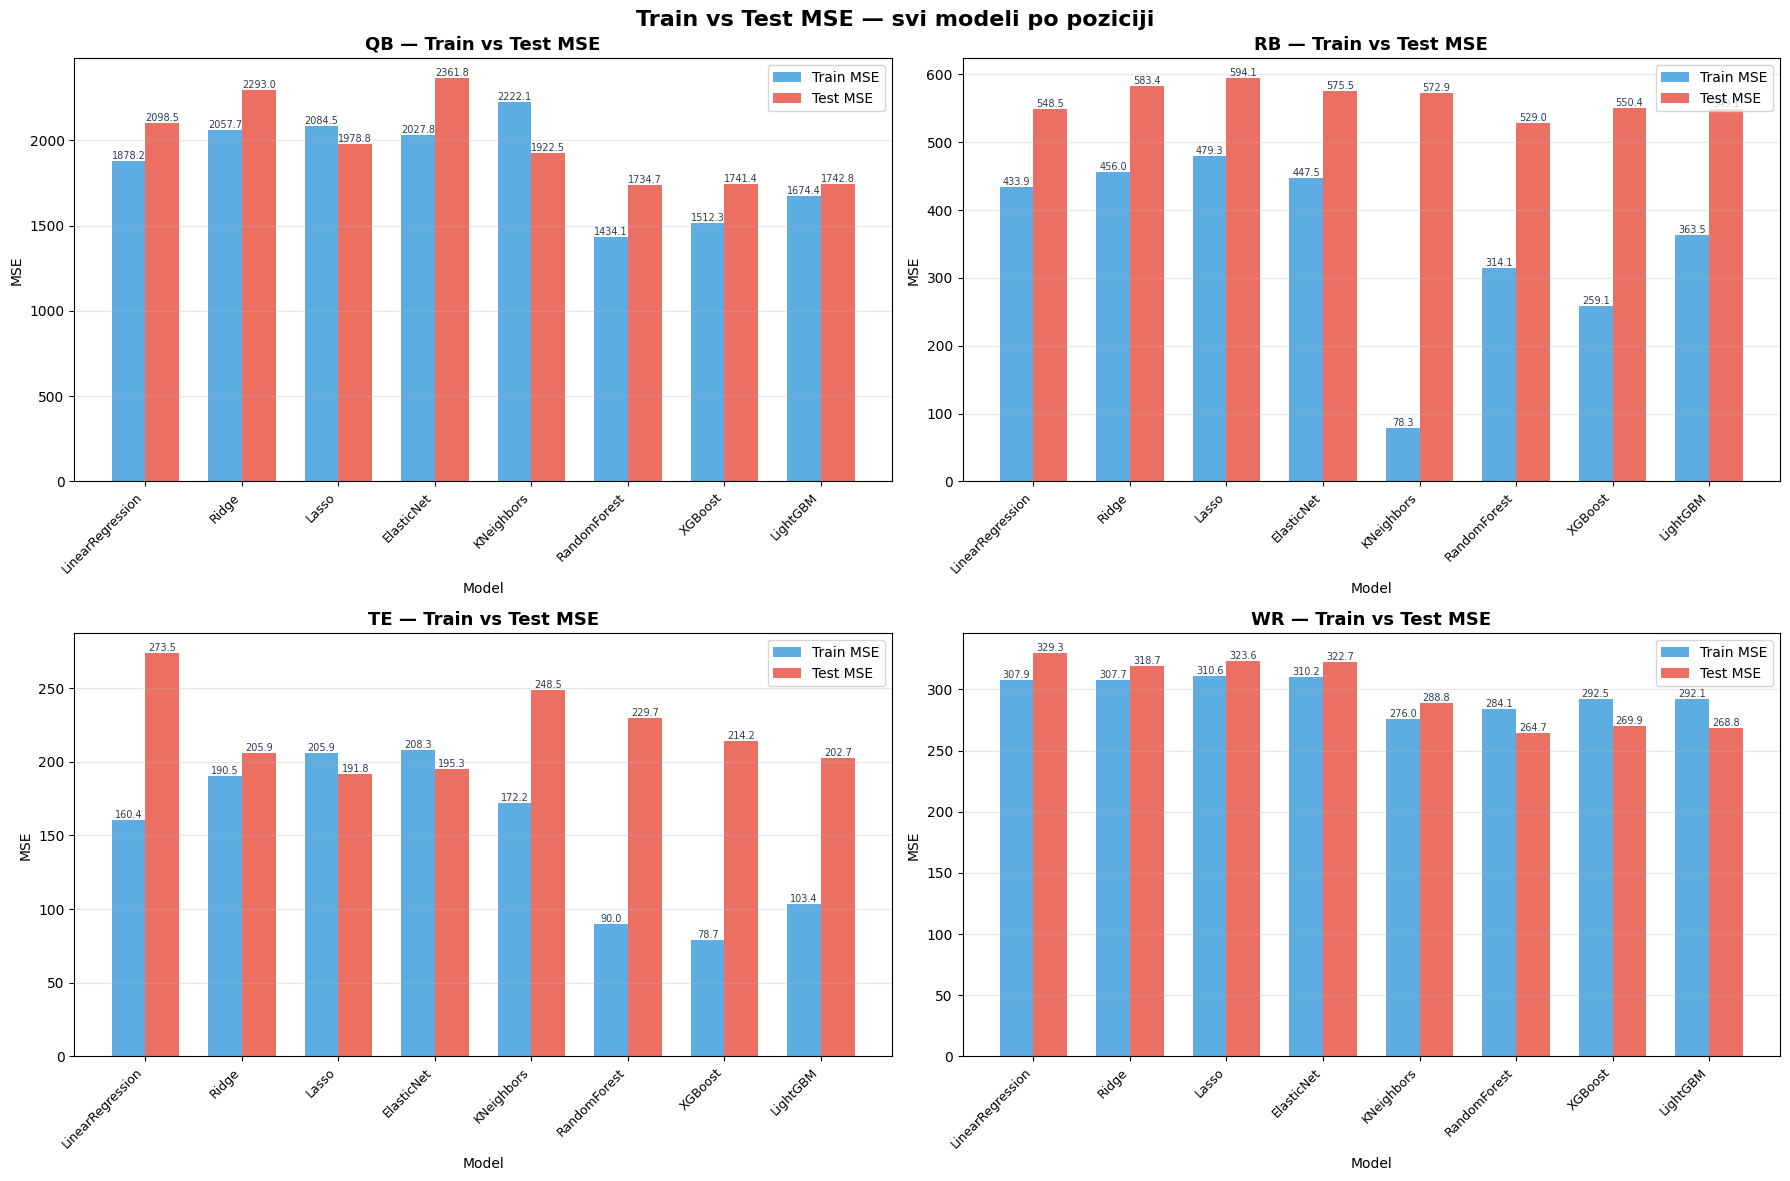

Analiza loss funkcije zavrsena.


In [38]:
import matplotlib.pyplot as plt
import numpy as np
import copy
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

POSITIONS = ['QB', 'RB', 'TE', 'WR']
ITERATIVE_MODELS = ['XGBoost', 'LightGBM']
NON_ITERATIVE_MODELS = ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'KNeighbors', 'RandomForest']

# ─────────────────────────────────────────────────────────────────────
# 1) ITERATIVNI MODELI — loss kriva po boosting rundama
# ─────────────────────────────────────────────────────────────────────

fig_iter, axes_iter = plt.subplots(len(POSITIONS), 2, figsize=(18, 5 * len(POSITIONS)),
                                   squeeze=False)
fig_iter.suptitle('Loss funkcija tokom treninga — XGBoost i LightGBM',
                  fontsize=16, fontweight='bold', y=1.01)

for row, pos in enumerate(POSITIONS):
    X_tr, X_te, y_tr, y_te = processed[pos]

    for col, model_name in enumerate(ITERATIVE_MODELS):
        ax = axes_iter[row][col]
        cfg = MODEL_CONFIGS[model_name]

        # Preuzmi best parametre iz vec istreniranog modela
        trained = best_estimators[pos][model_name]
        best_params = trained.get_params()

        # Kreiraj novi model sa istim parametrima ali sa eval_set praćenjem
        if model_name == 'XGBoost':
            n_est = best_params.get('n_estimators', 200)
            model = XGBRegressor(
                **{k: v for k, v in best_params.items()
                   if k in ['max_depth', 'learning_rate', 'subsample',
                            'n_estimators', 'random_state', 'n_jobs',
                            'reg_alpha', 'reg_lambda', 'colsample_bytree',
                            'min_child_weight', 'gamma']},
                verbosity=0,
                eval_metric='rmse',
            )
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_tr, y_tr), (X_te, y_te)],
                verbose=False,
            )
            results = model.evals_result()
            train_loss = results['validation_0']['rmse']
            test_loss = results['validation_1']['rmse']

        else:  # LightGBM
            n_est = best_params.get('n_estimators', 200)
            model = LGBMRegressor(
                **{k: v for k, v in best_params.items()
                   if k in ['max_depth', 'learning_rate', 'n_estimators',
                            'num_leaves', 'random_state', 'n_jobs',
                            'reg_alpha', 'reg_lambda', 'min_child_samples',
                            'subsample', 'colsample_bytree']},
                verbosity=-1,
                metric='rmse',
            )
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_tr, y_tr), (X_te, y_te)],
                eval_metric='rmse',
            )
            results = model.evals_result_
            # LightGBM koristi 'training'/'valid_1' ili slicne kljuceve
            keys = list(results.keys())
            train_key, test_key = keys[0], keys[1]
            metric_key = list(results[train_key].keys())[0]
            train_loss = results[train_key][metric_key]
            test_loss = results[test_key][metric_key]

        epochs = range(1, len(train_loss) + 1)
        ax.plot(epochs, train_loss, label='Train RMSE', color='#3498db', linewidth=1.5)
        ax.plot(epochs, test_loss, label='Test RMSE', color='#e74c3c', linewidth=1.5)
        ax.set_title(f'{pos} — {model_name}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Boosting runda')
        ax.set_ylabel('RMSE')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

        # Oznaci min test loss
        min_idx = np.argmin(test_loss)
        ax.axvline(x=min_idx + 1, color='#e74c3c', linestyle='--', alpha=0.5)
        ax.annotate(f'Min test: {test_loss[min_idx]:.3f}\n(runda {min_idx+1})',
                    xy=(min_idx + 1, test_loss[min_idx]),
                    xytext=(15, 15), textcoords='offset points',
                    fontsize=9, color='#e74c3c',
                    arrowprops=dict(arrowstyle='->', color='#e74c3c', alpha=0.7))

fig_iter.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────
# 2) SVI MODELI — Train vs Test loss poredjenje
# ─────────────────────────────────────────────────────────────────────

all_models = NON_ITERATIVE_MODELS + ITERATIVE_MODELS

fig_bar, axes_bar = plt.subplots(2, 2, figsize=(18, 12))
fig_bar.suptitle('Train vs Test MSE — svi modeli po poziciji',
                 fontsize=16, fontweight='bold')

for idx, pos in enumerate(POSITIONS):
    ax = axes_bar[idx // 2][idx % 2]
    X_tr, X_te, y_tr, y_te = processed[pos]
    is_wr = (pos == 'WR')

    model_names = []
    train_mses = []
    test_mses = []

    for name in all_models:
        if name not in best_estimators[pos]:
            continue
        model = best_estimators[pos][name]
        pred_tr = model.predict(X_tr)
        pred_te = model.predict(X_te)

        if is_wr:
            t_mse = mean_squared_error(np.expm1(y_tr), np.expm1(pred_tr))
            te_mse = mean_squared_error(np.expm1(y_te), np.expm1(pred_te))
        else:
            t_mse = mean_squared_error(y_tr, pred_tr)
            te_mse = mean_squared_error(y_te, pred_te)

        model_names.append(name)
        train_mses.append(t_mse)
        test_mses.append(te_mse)

    x = np.arange(len(model_names))
    width = 0.35
    bars1 = ax.bar(x - width/2, train_mses, width, label='Train MSE', color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, test_mses, width, label='Test MSE', color='#e74c3c', alpha=0.8)

    ax.set_title(f'{pos} — Train vs Test MSE', fontsize=13, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel('MSE')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Dodaj vrednosti na barove
    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.1f}',
                ha='center', va='bottom', fontsize=7, color='#2c3e50')
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.1f}',
                ha='center', va='bottom', fontsize=7, color='#2c3e50')

fig_bar.tight_layout()
plt.show()

print('Analiza loss funkcije zavrsena.')